# Part 2 Slide Visuals - Refined EDA Notebook
## AUS/NZ Producer Prices, Global Hunger and Food-Import Exposure

This refined notebook is designed as the analyst handoff for the Part 2 presentation. Key visual headings are mapped to the draft deck slide where they belong, and all plots use a consistent **Magma** palette to match the Streamlit dashboard.

**Framing:** the analysis identifies structural exposure to global food-price pressure. It does not prove direct bilateral import dependence on Australia or New Zealand.

---
## 0. Setup & Load All Cleaned Files


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from openpyxl import load_workbook
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Consistent Magma visual system for notebook and dashboard alignment.
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

CMAP = mpl.colormaps['magma']
MAGMA = [mpl.colors.to_hex(CMAP(x)) for x in np.linspace(0.08, 0.92, 8)]
COLORS = {
    'AUS': MAGMA[2],
    'NZL': MAGMA[5],
    'FFPI': MAGMA[0],
    'danger': MAGMA[5],
    'safe': MAGMA[2],
    'warn': MAGMA[4],
    'muted': '#d7d7df',
    'ink': '#232038',
    'light': MAGMA[7],
}
RISK_CMAP = 'magma'

In [3]:
# Resolve paths from the repository root so the notebook runs outside Colab.
def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'README.md').exists() and (candidate / 'data').exists():
            return candidate
    return start.resolve()

ROOT_DIR = find_repo_root(Path.cwd())
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
RAW_DIR = ROOT_DIR / 'data' / 'raw'
print(f'Repo root: {ROOT_DIR}')

Repo root: C:\Users\ThinkPad\Projects\assignment3-faostat-viz


In [4]:
# Load all cleaned files from the project repository.
master_usd = pd.read_csv(PROCESSED_DIR / 'master_producer_prices_usd.csv')
master_idx = pd.read_csv(PROCESSED_DIR / 'master_producer_price_index.csv')
ffpi_m     = pd.read_csv(PROCESSED_DIR / 'ffpi_monthly.csv', parse_dates=['date'])
ffpi_a     = pd.read_csv(PROCESSED_DIR / 'ffpi_annual.csv')
ghi        = pd.read_csv(PROCESSED_DIR / 'ghi_cleaned.csv')
wb         = pd.read_csv(PROCESSED_DIR / 'worldbank_food_import_pct.csv')

# Convenience splits
aus = master_usd[master_usd['iso3'] == 'AUS'].copy()
nzl = master_usd[master_usd['iso3'] == 'NZL'].copy()

print('All files loaded.')
print(f'   master_usd : {master_usd.shape}')
print(f'   master_idx : {master_idx.shape}')
print(f'   ffpi_m     : {ffpi_m.shape}')
print(f'   ghi        : {ghi.shape}')
print(f'   worldbank  : {wb.shape}')

All files loaded.
   master_usd : (3033, 27)
   master_idx : (6532, 27)
   ffpi_m     : (435, 9)
   ghi        : (136, 8)
   worldbank  : (9984, 4)


---
## Slide Appendix - Dataset Overview and Structure


In [5]:
print('MASTER USD — Shape & Columns')
print(f'Rows: {len(master_usd):,}   Columns: {master_usd.shape[1]}')
print()
print('Column dtypes:')
print(master_usd.dtypes.to_string())


MASTER USD — Shape & Columns
Rows: 3,033   Columns: 27

Column dtypes:
Domain Code             str
Domain                  str
Area Code (M49)       int64
country                 str
Element Code          int64
element                 str
Item Code (CPC)         str
item                    str
Year Code             int64
year                  int64
Months Code           int64
month                   str
unit                    str
value               float64
flag                    str
flag_description        str
iso3                    str
is_imputed             bool
is_outlier             bool
ffpi_food           float64
ffpi_meat           float64
ffpi_dairy          float64
ffpi_cereals        float64
ffpi_oils           float64
ffpi_sugar          float64
food_import_pct     float64
ghi_2025            float64


In [6]:
print('Countries and year coverage:')
cov = master_usd.groupby('country')['year'].agg(['min','max','count'])
cov.columns = ['first_year','last_year','n_observations']
print(cov.to_string())
print()
print(f'Total unique commodities: {master_usd["item"].nunique()}')
print(f'  AUS: {aus["item"].nunique()} commodities')
print(f'  NZL: {nzl["item"].nunique()} commodities')


Countries and year coverage:
             first_year  last_year  n_observations
country                                           
Australia          1991       2024            2131
New Zealand        1991       2024             902

Total unique commodities: 96
  AUS: 92 commodities
  NZL: 51 commodities


In [7]:
print('Month distribution (should all be Annual value for this download):')
print(master_usd['month'].value_counts())
print()
print('Flag breakdown:')
print(master_usd['flag'].value_counts())
print()
print('Imputed rows:', master_usd['is_imputed'].sum())
print('Outlier rows:', master_usd['is_outlier'].sum())


Month distribution (should all be Annual value for this download):
month
Annual value    3033
Name: count, dtype: int64

Flag breakdown:
flag
A    3029
X       4
Name: count, dtype: int64

Imputed rows: 4
Outlier rows: 24


In [8]:
# Statistical summary of producer prices
print('Descriptive Statistics — USD/tonne')
stats = master_usd.groupby('country')['value'].describe().round(2)
print(stats.to_string())


Descriptive Statistics — USD/tonne


              count     mean      std   min    25%     50%      75%      max
country                                                                     
Australia    2131.0  1386.27  2073.52  11.9  285.2  699.10  1687.15  36133.4
New Zealand   902.0  1097.03  1147.71  56.8  272.1  698.35  1543.92   8002.3


---
## Slide Appendix - Missing Value and Data Quality Checks


In [9]:
null_counts = master_usd.isnull().sum()
null_pct    = (null_counts / len(master_usd) * 100).round(1)
null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df = null_df[null_df['null_count'] > 0]
print('Columns with missing values:')
print(null_df.to_string())
print()
print('Why ghi_2025 = NaN for all rows:')
print('  AUS and NZL are high-income nations not included in GHI rankings.')
print('  This is correct. The GHI data is used for the GLOBAL hunger context panel,')
print('  not for the AUS/NZL rows themselves.')
print()
print('ghi_cleaned.csv coverage:')
print(f'  Countries with GHI 2025 score: {ghi["ghi_2025"].notna().sum()}')
print(f'  Countries missing GHI 2025:   {ghi["ghi_2025"].isna().sum()} (use 2016 or 2008 as fallback)')


Columns with missing values:
          null_count  null_pct
ghi_2025        3033     100.0

Why ghi_2025 = NaN for all rows:
  AUS and NZL are high-income nations not included in GHI rankings.
  This is correct. The GHI data is used for the GLOBAL hunger context panel,
  not for the AUS/NZL rows themselves.

ghi_cleaned.csv coverage:
  Countries with GHI 2025 score: 98
  Countries missing GHI 2025:   38 (use 2016 or 2008 as fallback)


---
## Slide Appendix - Commodity Price Structure


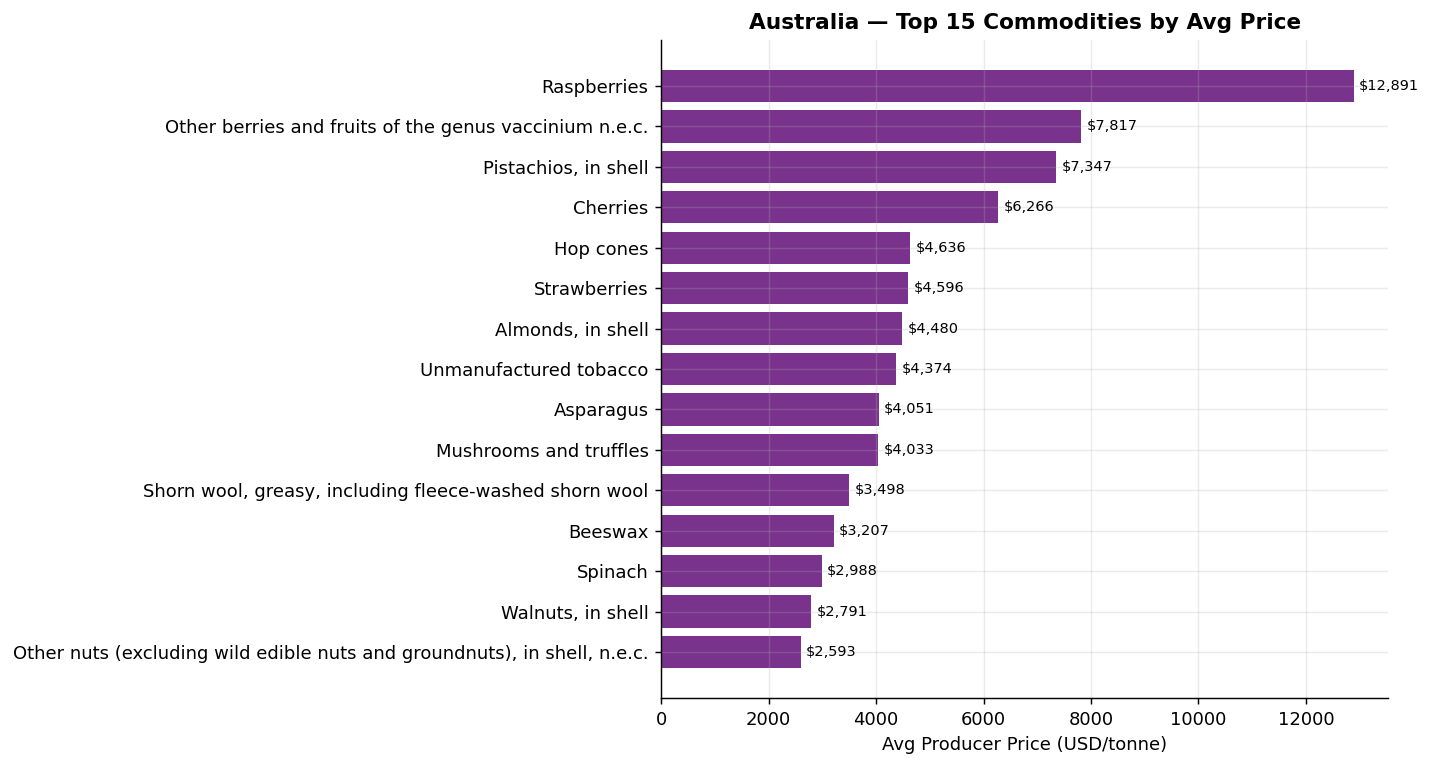

In [10]:
# Top 15 highest average priced commodities — Australia
top_aus = (aus.groupby('item')['value'].mean().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_aus.index[::-1], top_aus.values[::-1], color=COLORS['AUS'], alpha=0.9)
ax.set_xlabel('Avg Producer Price (USD/tonne)')
ax.set_title('Australia — Top 15 Commodities by Avg Price', fontweight='bold')
for i, v in enumerate(top_aus.values[::-1]):
    ax.text(v + 100, i, f'${v:,.0f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


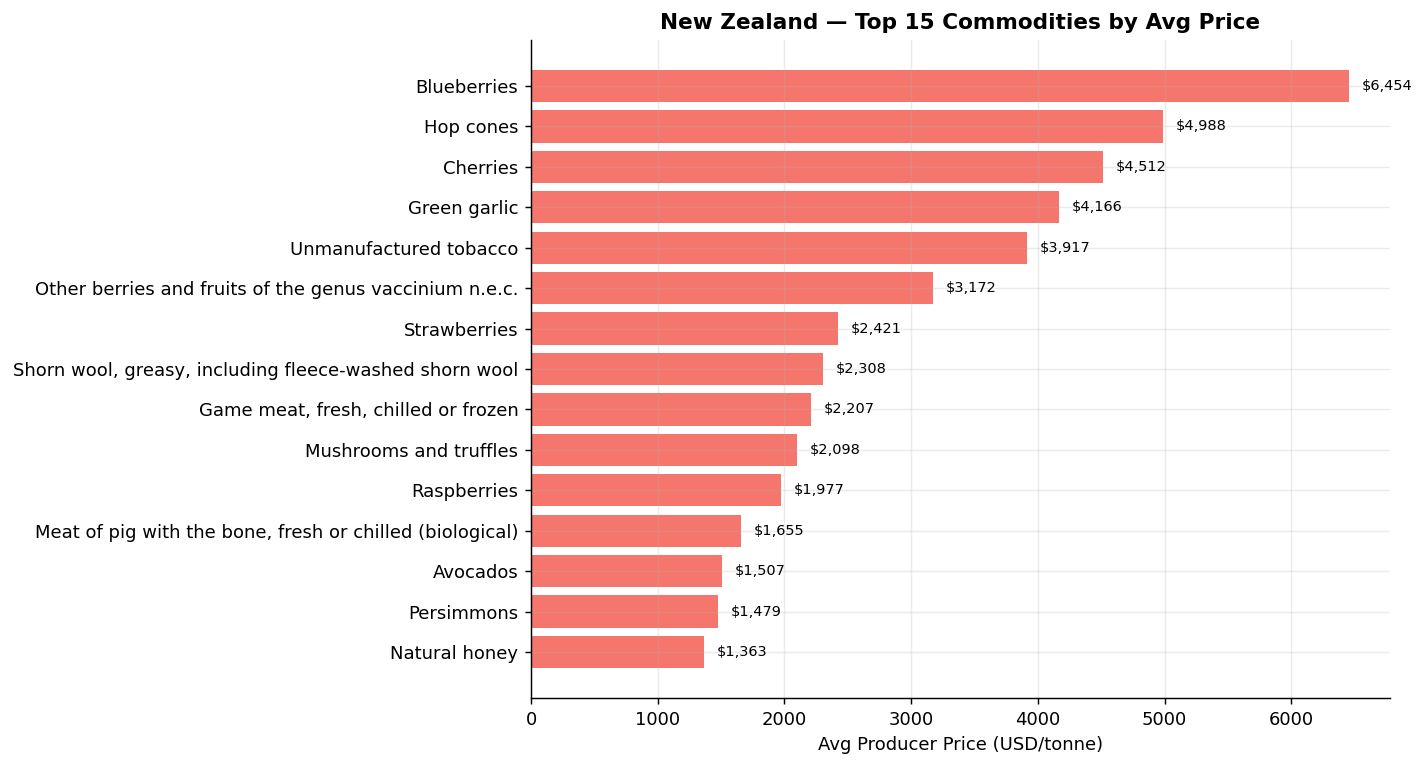

In [11]:
# Top 15 highest average priced commodities — New Zealand
top_nzl = (nzl.groupby('item')['value'].mean().sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_nzl.index[::-1], top_nzl.values[::-1], color=COLORS['NZL'], alpha=0.9)
ax.set_xlabel('Avg Producer Price (USD/tonne)')
ax.set_title('New Zealand — Top 15 Commodities by Avg Price', fontweight='bold')
for i, v in enumerate(top_nzl.values[::-1]):
    ax.text(v + 100, i, f'${v:,.0f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()


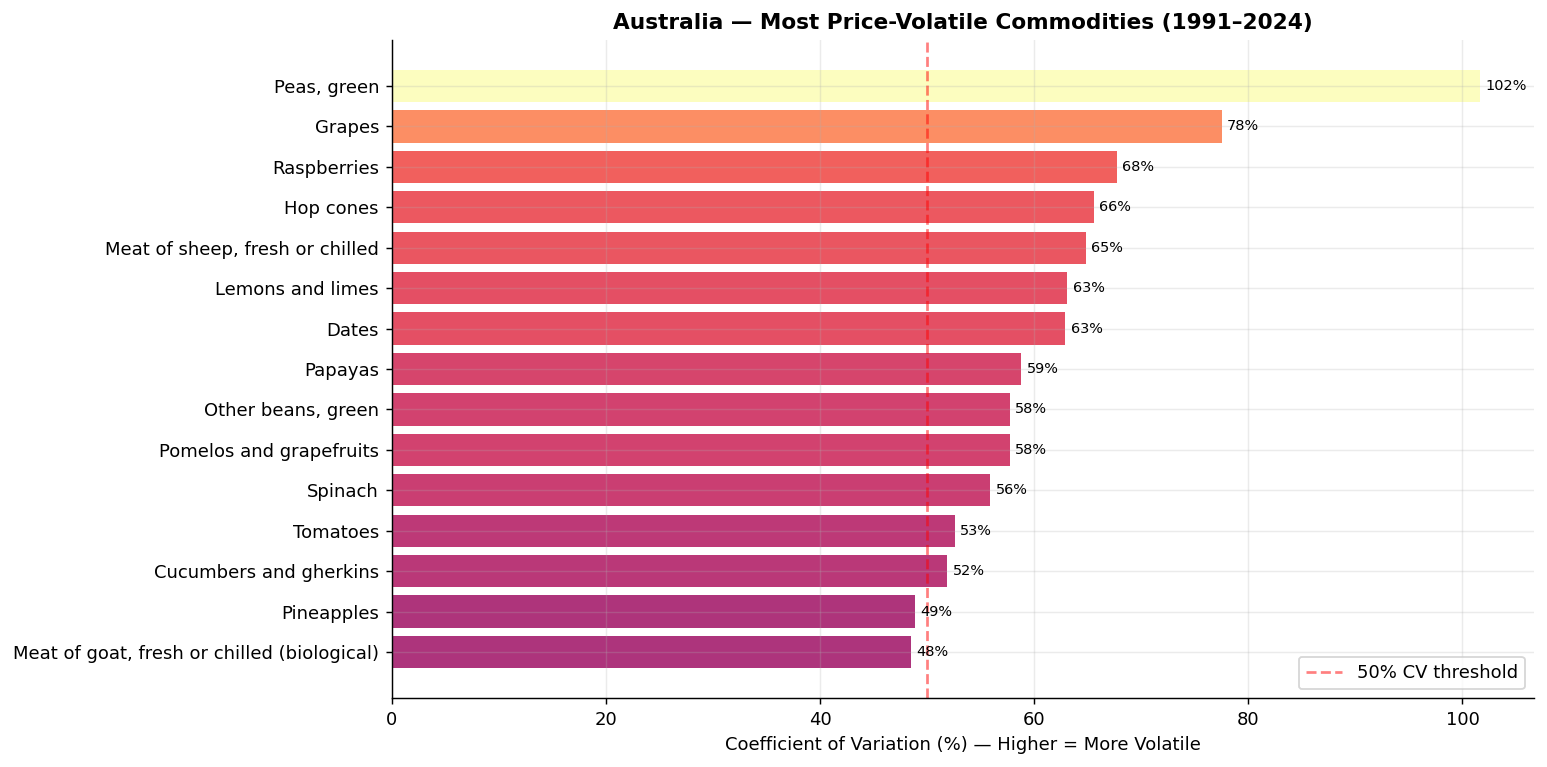

In [12]:
# Price volatility — Coefficient of Variation (CV = std/mean) per commodity
cv_aus = aus.groupby('item')['value'].agg(['mean','std'])
cv_aus['cv'] = (cv_aus['std'] / cv_aus['mean'] * 100).round(1)
cv_aus = cv_aus.sort_values('cv', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_cv = cv_aus.head(15)
bars = ax.barh(top_cv.index[::-1], top_cv['cv'].values[::-1], color=CMAP(top_cv['cv'].values[::-1] / top_cv['cv'].max()))
ax.set_xlabel('Coefficient of Variation (%) — Higher = More Volatile')
ax.set_title('Australia — Most Price-Volatile Commodities (1991–2024)', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% CV threshold')
for i, (idx, row) in enumerate(top_cv.iloc[::-1].iterrows()):
    ax.text(row['cv'] + 0.5, i, f"{row['cv']:.0f}%", va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
print('Most volatile commodities (CV > 50%):')
print(cv_aus[cv_aus['cv']>50][['mean','std','cv']].round(2).to_string())

Most volatile commodities (CV > 50%):
                                     mean      std     cv
item                                                     
Peas, green                        405.03   411.42  101.6
Grapes                             664.15   514.71   77.5
Raspberries                      12891.43  8721.95   67.7
Hop cones                         4635.64  3040.67   65.6
Meat of sheep, fresh or chilled   2292.53  1484.45   64.8
Lemons and limes                   785.66   495.72   63.1
Dates                             2429.82  1528.15   62.9
Papayas                            982.39   578.05   58.8
Other beans, green                1937.51  1118.28   57.7
Pomelos and grapefruits            571.62   329.82   57.7
Spinach                           2988.13  1668.88   55.9
Tomatoes                           649.08   341.37   52.6
Cucumbers and gherkins            1076.07   558.68   51.9


---
## Slide 4 - AUS/NZ Wheat Producer Price Signal

For each staple, we plot AUS and NZL producer prices over time, with three
crisis zones shaded. The **wheat chart leads** — visually highlighted because
it is our indicator commodity for the rest of the analysis.

In [14]:
# Key commodities for time series
KEY_ITEMS = ['Wheat', 'Barley', 'Maize (corn)', 'Rice','Raw milk of cattle', 'Meat of cattle with the bone',
             'fresh or chilled','Soya beans', 'Canola (Rape or colza seed)']

# Filter — use whatever is available in AUS
available = [i for i in KEY_ITEMS if i in aus['item'].values]
if 'Rape or colza seed' in aus['item'].values:
    available.append('Rape or colza seed')
print('Available key items:', available)


Available key items: ['Wheat', 'Barley', 'Maize (corn)', 'Rice', 'Raw milk of cattle', 'Soya beans', 'Rape or colza seed']


In [15]:
# Crisis zones used across the time-series and FFPI charts
CRISIS_ZONES = [
    (2007, 2009, '#fde0dd', '2007–09\nFood Crisis'),
    (2010, 2012, '#fce6c9', '2010–11\nArab Spring'),
    (2021, 2023, '#fde0dd', '2022\nUkraine War'),
]


### Slide 4 - Wheat Producer Prices vs Global Food Price Index

**Visual design choices applied:**
- *Position & length* (Cleveland & McGill's most accurate channel) carries the data — straight line plot.
- *Saturation* separates focal (AUS, saturated Magma purple) from supporting (NZL, Magma coral) and context (5-year rolling mean, muted).
- *Annotation at point of interest* — the three crisis peaks are directly labelled with year and YoY change, so the eye doesn't need to round-trip to a legend.
- *Crisis bands* use very low-alpha red fills (figure-ground separation without competing with the lines).
- *Direct end-of-line labels* replace a legend (one less saccade).

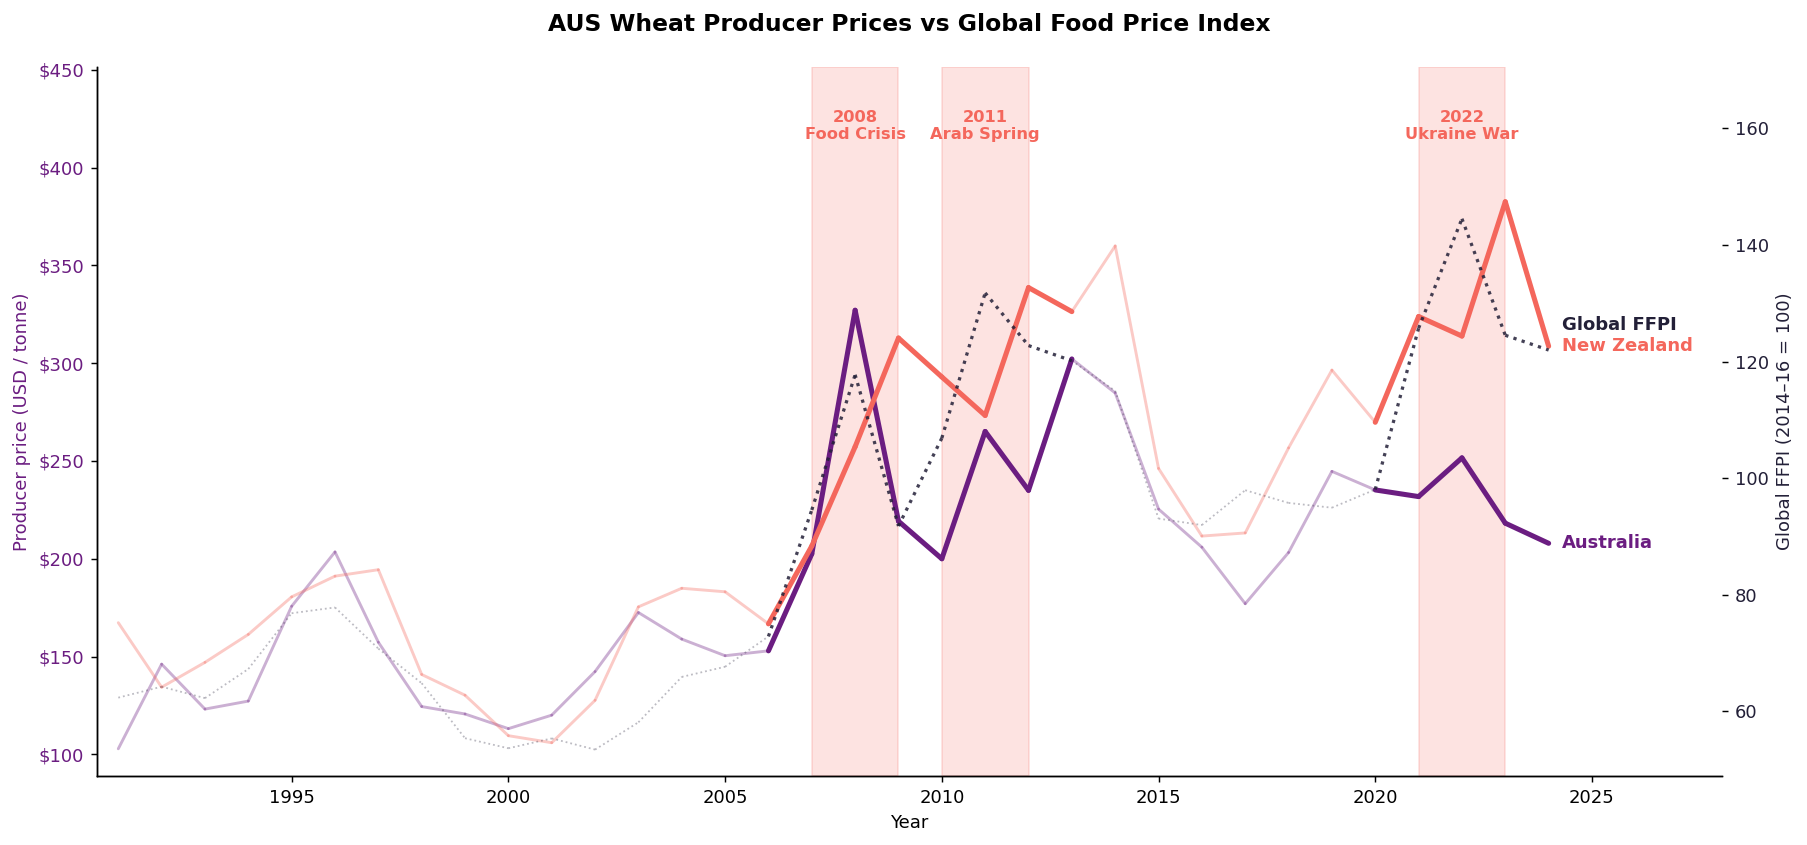

In [16]:
# === REDESIGNED CHART: AUS Wheat + Global FFPI overlay ===
wheat_aus = aus[aus['item'] == 'Wheat'].sort_values('year').reset_index(drop=True).copy()
wheat_nzl = nzl[nzl['item'] == 'Wheat'].sort_values('year').reset_index(drop=True).copy()
wheat_aus['yoy'] = wheat_aus['value'].pct_change() * 100

# Crisis range bands
CRISIS_BANDS = [
    (2007, 2009, '2008\nFood Crisis'),
    (2010, 2012, '2011\nArab Spring'),
    (2021, 2023, '2022\nUkraine War'),
]

fig, ax = plt.subplots(figsize=(14, 6.6))
ax.grid(False)

# Secondary axis for the FFPI — different units (index), needs its own scale
ax2 = ax.twinx()
ax2.grid(False)

# 1. Light-red crisis range bands
for start, end, _ in CRISIS_BANDS:
    ax.axvspan(start, end, alpha=0.18, color=COLORS['danger'], zorder=0)

# 2. Helper — plot a line in two segments
def plot_segmented(target_ax, years_arr, values, color,
                   base_lw=1.6, bold_lw=2.8,
                   base_alpha=0.35, bold_alpha=1.0, linestyle='-'):
    years_arr  = np.asarray(years_arr)
    values_arr = np.asarray(values)
    in_band = np.zeros(len(years_arr), dtype=bool)
    for start, end, _ in CRISIS_BANDS:
        in_band |= (years_arr >= start) & (years_arr <= end)
    for i in range(len(years_arr) - 1):
        x = [years_arr[i], years_arr[i + 1]]
        y = [values_arr[i], values_arr[i + 1]]
        if in_band[i] or in_band[i + 1]:
            target_ax.plot(x, y, color=color, linewidth=bold_lw, alpha=bold_alpha,
                           linestyle=linestyle, zorder=3, solid_capstyle='round')
        else:
            target_ax.plot(x, y, color=color, linewidth=base_lw, alpha=base_alpha,
                           linestyle=linestyle, zorder=2, solid_capstyle='round')

# 3. Plot lines
# AUS focal — solid blue
plot_segmented(ax, wheat_aus['year'], wheat_aus['value'], COLORS['AUS'])
# NZL supporting — solid orange (was dashed)
plot_segmented(ax, wheat_nzl['year'], wheat_nzl['value'], COLORS['NZL'])

# Global FFPI — right axis, dotted, dark anchor
ffpi_overlay = ffpi_a[
    (ffpi_a['year'] >= wheat_aus['year'].min()) &
    (ffpi_a['year'] <= wheat_aus['year'].max())
].sort_values('year').reset_index(drop=True)

plot_segmented(ax2, ffpi_overlay['year'], ffpi_overlay['ffpi_food'],
               COLORS['ink'],
               base_lw=1.0, bold_lw=1.8,
               base_alpha=0.30, bold_alpha=0.85,
               linestyle=':')

# 4. End-of-line labels — collect from BOTH axes, deconflict together
last_year_aus  = wheat_aus['year'].iloc[-1]
last_aus       = wheat_aus['value'].iloc[-1]
last_nzl_row   = wheat_nzl.dropna(subset=['value']).iloc[-1]
last_ffpi_year = ffpi_overlay['year'].iloc[-1]
last_ffpi      = ffpi_overlay['ffpi_food'].iloc[-1]

# Convert FFPI value to the LEFT-axis coordinate space so we can compare
# vertical positions across both axes for deconfliction
def ffpi_to_left_y(v):
    # Map v from ax2's y-range onto ax's y-range proportionally
    a2_min, a2_max = ax2.get_ylim()
    a1_min, a1_max = ax.get_ylim()
    return a1_min + (v - a2_min) / (a2_max - a2_min) * (a1_max - a1_min)

# Build label list using left-axis coordinates so spacing is honest
labels = [
    {'y_left': last_aus,                 'lab': 'Australia',   'color': COLORS['AUS'],
     'axis': ax,  'x': last_year_aus + 0.3, 'true_y': last_aus},
    {'y_left': last_nzl_row['value'],    'lab': 'New Zealand', 'color': COLORS['NZL'],
     'axis': ax,  'x': last_year_aus + 0.3, 'true_y': last_nzl_row['value']},
    {'y_left': ffpi_to_left_y(last_ffpi),'lab': 'Global FFPI', 'color': COLORS['ink'],
     'axis': ax2, 'x': last_ffpi_year + 0.3, 'true_y': last_ffpi},
]
labels.sort(key=lambda d: d['y_left'])

# Walk through and push each label up if it's too close to the previous one
MIN_GAP_LEFT = 18   # in left-axis units (USD/tonne)
for i in range(1, len(labels)):
    if labels[i]['y_left'] - labels[i - 1]['y_left'] < MIN_GAP_LEFT:
        shift = MIN_GAP_LEFT - (labels[i]['y_left'] - labels[i - 1]['y_left'])
        labels[i]['y_left'] += shift
        # If this label belongs to ax2, convert the new left-axis y back to ax2's scale
        if labels[i]['axis'] is ax2:
            a2_min, a2_max = ax2.get_ylim()
            a1_min, a1_max = ax.get_ylim()
            labels[i]['true_y'] = a2_min + (labels[i]['y_left'] - a1_min) / (a1_max - a1_min) * (a2_max - a2_min)
        else:
            labels[i]['true_y'] = labels[i]['y_left']

for d in labels:
    d['axis'].text(d['x'], d['true_y'], d['lab'],
                   color=d['color'], fontweight='bold', fontsize=10, va='center')

# 5. Event labels
data_max = max(wheat_aus['value'].max(),
               wheat_nzl['value'].max() if len(wheat_nzl) else 0)
y_label = data_max * 1.08
ax.set_ylim(top=data_max * 1.18)
ffpi_max = ffpi_overlay['ffpi_food'].max()
ax2.set_ylim(top=ffpi_max * 1.18)

for start, end, lbl in CRISIS_BANDS:
    ax.text((start + end) / 2, y_label, lbl,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=COLORS['danger'])

# 6. Title & axes
ax.set_xlabel('Year')
ax.set_ylabel('Producer price (USD / tonne)', color=COLORS['AUS'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='y', labelcolor=COLORS['AUS'])

ax2.set_ylabel('Global FFPI (2014–16 = 100)', color=COLORS['ink'])
ax2.tick_params(axis='y', labelcolor=COLORS['ink'])
ax2.spines['top'].set_visible(False)

ax.set_title('AUS Wheat Producer Prices vs Global Food Price Index',
             fontweight='bold', fontsize=13, pad=20)
ax.set_xlim(wheat_aus['year'].iloc[0] - 0.5, last_year_aus + 4)

plt.tight_layout()
plt.show()

### Appendix Visual - Other Staple Commodity Price Signals

The remaining three staples (Barley, Maize, Rice or whichever are present)
each get their own canvas. The chart style is intentionally simpler than
the wheat lead — less ink, less narrative, since the point of these is to
confirm that the storm pattern generalises beyond wheat.

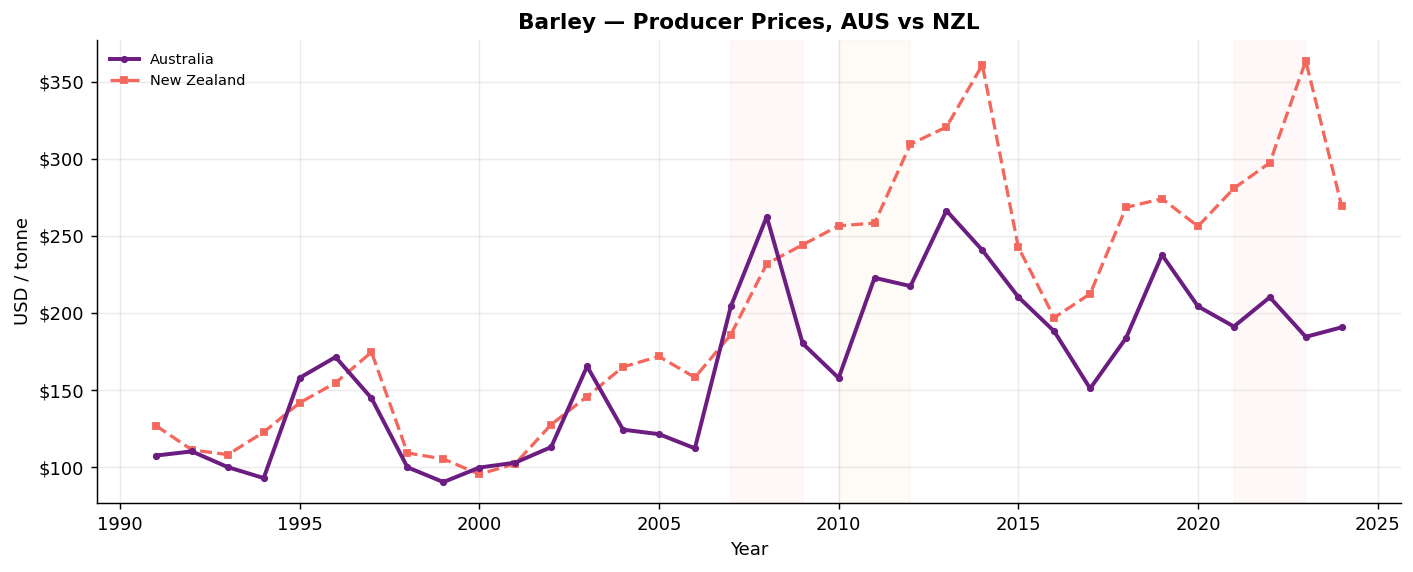

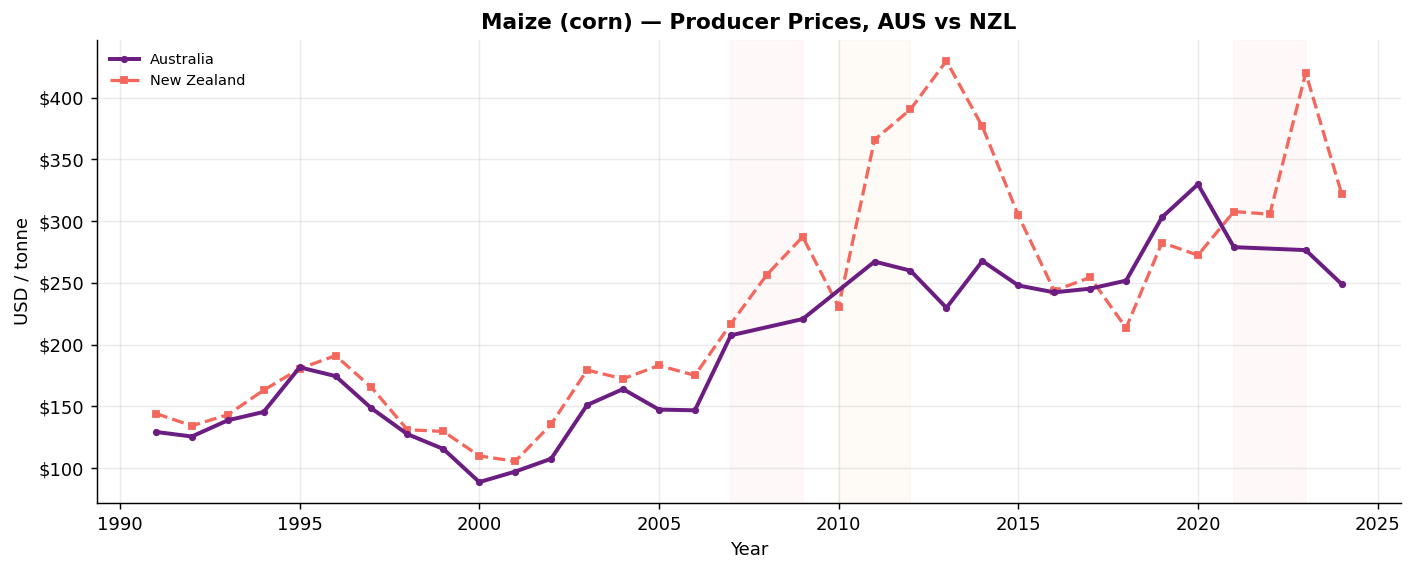

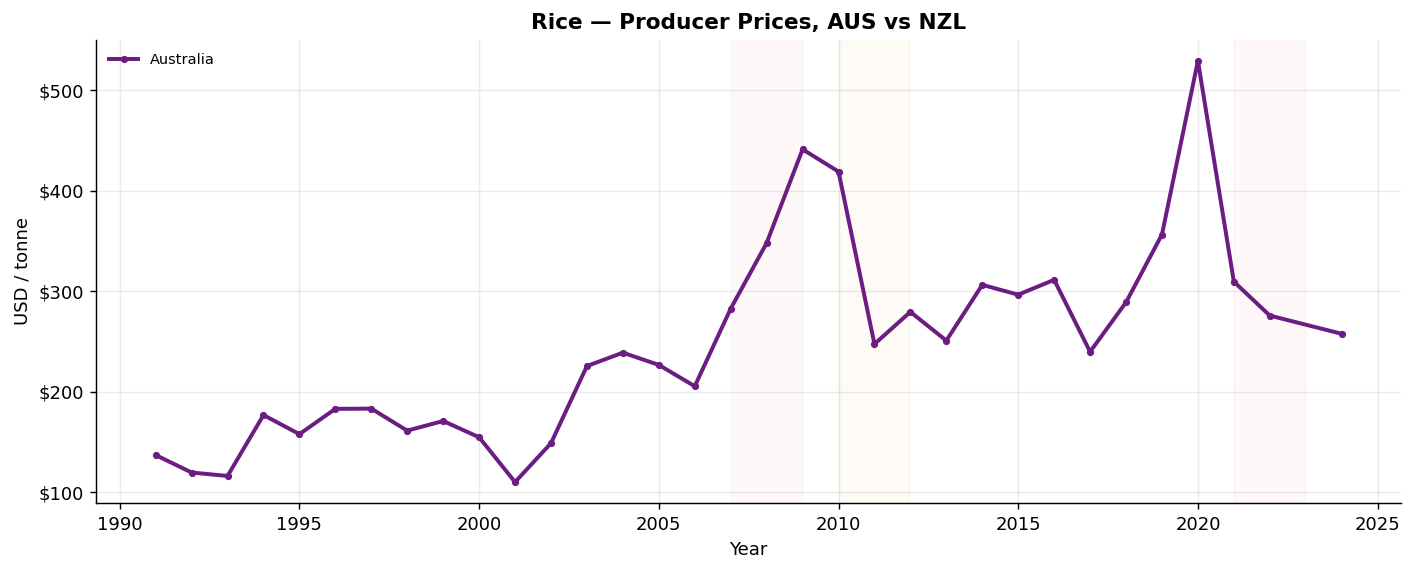

In [17]:
# Plot remaining staples — one per canvas. Skip wheat (already shown above).
other_items = [
    i for i in ['Barley', 'Maize (corn)', 'Rice', 'Soya beans',
                'Raw milk of cattle', 'Rape or colza seed', 'Sorghum']
    if i in aus['item'].values
][:3]

for item in other_items:
    aus_ts = aus[aus['item'] == item].sort_values('year')
    nzl_ts = nzl[nzl['item'] == item].sort_values('year')

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for start, end, color, _ in CRISIS_ZONES:
        ax.axvspan(start, end, alpha=0.18, color=color, zorder=0)

    ax.plot(aus_ts['year'], aus_ts['value'], color=COLORS['AUS'],
            linewidth=2.2, marker='o', markersize=3, label='Australia',
            zorder=3)
    if len(nzl_ts) > 0:
        ax.plot(nzl_ts['year'], nzl_ts['value'], color=COLORS['NZL'],
                linewidth=1.8, linestyle='--', marker='s', markersize=3,
                label='New Zealand', zorder=2)

    out = aus_ts[aus_ts['is_outlier']]
    if len(out) > 0:
        ax.scatter(out['year'], out['value'], color=COLORS['danger'],
                   s=60, zorder=4, label='Outlier flagged')

    ax.set_xlabel('Year')
    ax.set_ylabel('USD / tonne')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'{item} — Producer Prices, AUS vs NZL', fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()


In [18]:
# Year-on-Year % change for key items
print('Year-on-Year Price Changes for Key Commodities (AUS):')
for item in [i for i in ['Wheat','Barley','Maize (corn)','Raw milk of cattle',
                          'Meat of cattle with the bone, fresh or chilled','Soya beans']
             if i in aus['item'].values]:
    sub = aus[aus['item']==item].sort_values('year')[['year','value']].copy()
    sub['yoy_pct'] = sub['value'].pct_change() * 100
    peak = sub.nlargest(1,'yoy_pct')
    trough = sub.nsmallest(1,'yoy_pct')
    print(f'{item[:45]:<45}')
    print(f'  Peak increase : +{peak["yoy_pct"].values[0]:.1f}% in {peak["year"].values[0]}')
    print(f'  Peak decrease :  {trough["yoy_pct"].values[0]:.1f}% in {trough["year"].values[0]}')


Year-on-Year Price Changes for Key Commodities (AUS):
Wheat                                        
  Peak increase : +61.5% in 2008
  Peak decrease :  -33.0% in 2009
Barley                                       
  Peak increase : +82.0% in 2007
  Peak decrease :  -31.4% in 2009
Maize (corn)                                 
  Peak increase : +41.3% in 2007
  Peak decrease :  -23.2% in 2000
Raw milk of cattle                           
  Peak increase : +50.1% in 2008
  Peak decrease :  -20.3% in 2009
Meat of cattle with the bone, fresh or chille
  Peak increase : +89.2% in 2020
  Peak decrease :  -25.0% in 2023
Soya beans                                   
  Peak increase : +95.1% in 2003
  Peak decrease :  -24.2% in 2000


---
## Slide 2 - Global FFPI Shock Context

### Slide 2 - FAO Food Price Index Shock Timeline

**Visual design choices applied:**
- *Reduce cognitive load* — only show the three sub-indices our narrative needs (cereals, meat, sugar) plus the composite Food index as a dark anchor. The original chart's six lines hurt legibility.
- *Saturation hierarchy* — cereals is the most saturated (it's the AUS/NZ story); meat and sugar are next; the composite Food line is dark and thin (context, not focal).
- *Direct end-of-line labels* replace the legend.
- *Crisis bands + anchored annotations* — the three peaks are called out directly on the cereal line.
- *Reference band 100–150 in the chart background* lets the audience see that 'above 100' is *above the 2014–16 baseline* — context for what a 'spike' actually means.

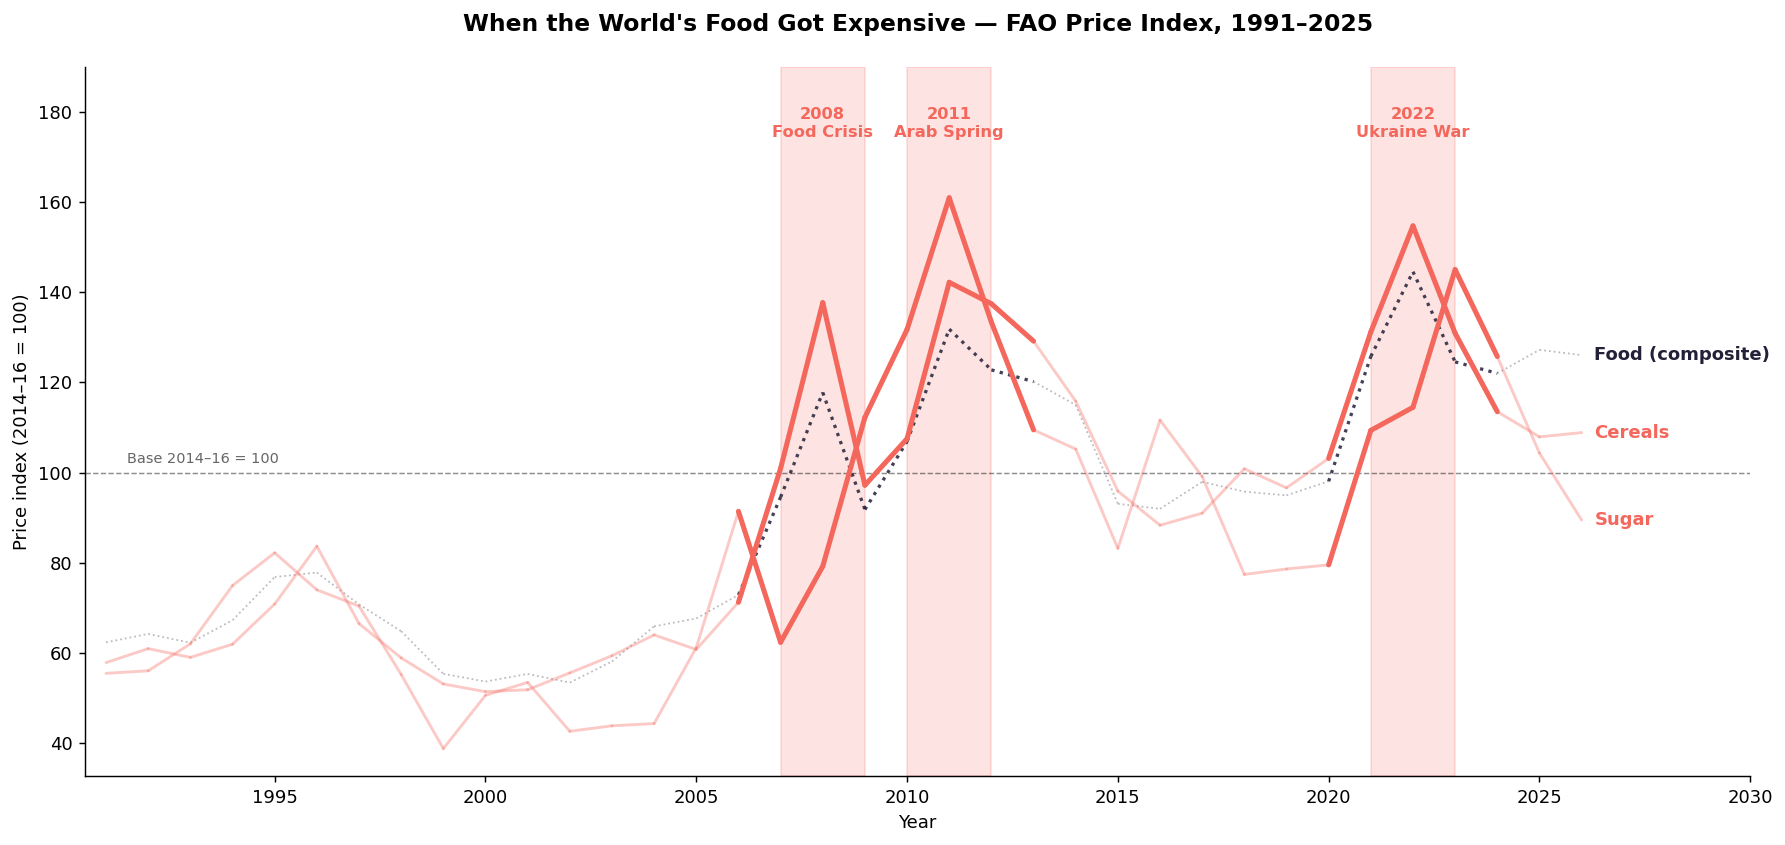

In [19]:
# === REDESIGNED CHART: FAO FFPI — Cereals + Sugar + Food composite ===
ffpi_plot = ffpi_a[ffpi_a['year'] >= 1991].copy().reset_index(drop=True)
years_arr  = ffpi_plot['year'].to_numpy()

# Three series: cereals & sugar as focal lines, food composite as dotted anchor
focal = {
    'ffpi_cereals': ('Cereals', COLORS['danger']),
    'ffpi_sugar':   ('Sugar',   COLORS['NZL']),
}
anchor_col, anchor_label, anchor_color = 'ffpi_food', 'Food (composite)', COLORS['ink']

# Crisis range bands
CRISIS_BANDS = [
    (2007, 2009, '2008\nFood Crisis'),
    (2010, 2012, '2011\nArab Spring'),
    (2021, 2023, '2022\nUkraine War'),
]

fig, ax = plt.subplots(figsize=(14, 6.6))
ax.grid(False)

# 1. Light-red crisis range bands
for start, end, _ in CRISIS_BANDS:
    ax.axvspan(start, end, alpha=0.18, color=COLORS['danger'], zorder=0)

# 2. Helper — plot a line in two segments: bold inside bands, light outside
def plot_segmented(years_arr, values, color, base_lw=1.6, bold_lw=2.8,
                   base_alpha=0.35, bold_alpha=1.0, linestyle='-'):
    values_arr = np.asarray(values)
    in_band = np.zeros(len(years_arr), dtype=bool)
    for start, end, _ in CRISIS_BANDS:
        in_band |= (years_arr >= start) & (years_arr <= end)
    for i in range(len(years_arr) - 1):
        x = [years_arr[i], years_arr[i + 1]]
        y = [values_arr[i], values_arr[i + 1]]
        if in_band[i] or in_band[i + 1]:
            ax.plot(x, y, color=color, linewidth=bold_lw, alpha=bold_alpha,
                    linestyle=linestyle, zorder=3, solid_capstyle='round')
        else:
            ax.plot(x, y, color=color, linewidth=base_lw, alpha=base_alpha,
                    linestyle=linestyle, zorder=2, solid_capstyle='round')

# 3. Plot lines (food composite first so it sits behind)
plot_segmented(years_arr, ffpi_plot[anchor_col],
               anchor_color, base_lw=1.0, bold_lw=1.8,
               base_alpha=0.30, bold_alpha=0.85, linestyle=':')
for col, (lab, color) in focal.items():
    plot_segmented(years_arr, ffpi_plot[col], color)

# 4. Baseline reference
ax.axhline(100, color='black', linewidth=0.8, linestyle='--',
           alpha=0.45, zorder=1)
ax.text(years_arr[0] + 0.5, 102, 'Base 2014–16 = 100',
        fontsize=8, color='#666')

# 5. Direct end-of-line labels (no legend)
last_year = years_arr[-1]
last_row = ffpi_plot.iloc[-1]
label_positions = [(last_row[col], lab, color) for col, (lab, color) in focal.items()]
label_positions.append((last_row[anchor_col], anchor_label, anchor_color))
label_positions.sort(key=lambda x: x[0])
prev_y = None
for y, lab, color in label_positions:
    if prev_y is not None and abs(y - prev_y) < 5:
        y = prev_y + 5
    ax.text(last_year + 0.3, y, lab,
            color=color, fontweight='bold', fontsize=10, va='center')
    prev_y = y

# 6. Event labels — placed in headroom ABOVE the data, below the title
data_max = ffpi_plot[list(focal.keys()) + [anchor_col]].max().max()
y_label = data_max * 1.08              # event labels sit above data
ax.set_ylim(top=data_max * 1.18)       # extra headroom so labels don't hit title
for start, end, lbl in CRISIS_BANDS:
    ax.text((start + end) / 2, y_label, lbl,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=COLORS['danger'])

# 7. Title & axes — default 5-year tick spacing
ax.set_xlabel('Year')
ax.set_ylabel('Price index (2014–16 = 100)')
ax.set_title("When the World's Food Got Expensive — FAO Price Index, 1991–2025",
             fontweight='bold', fontsize=13, pad=20)
ax.set_xlim(years_arr[0] - 0.5, last_year + 4)

plt.tight_layout()
plt.show()

### Slide 4 Backup - AUS/NZ Producer Price Index Alignment with FFPI

Twin-axis plot — left axis: AUS/NZL local producer price index; right axis:
the global FFPI Food composite. Same chart as the original EDA — it's already
a single canvas, and the dual axis is justified because the *correlation* is
the message, not the absolute levels.


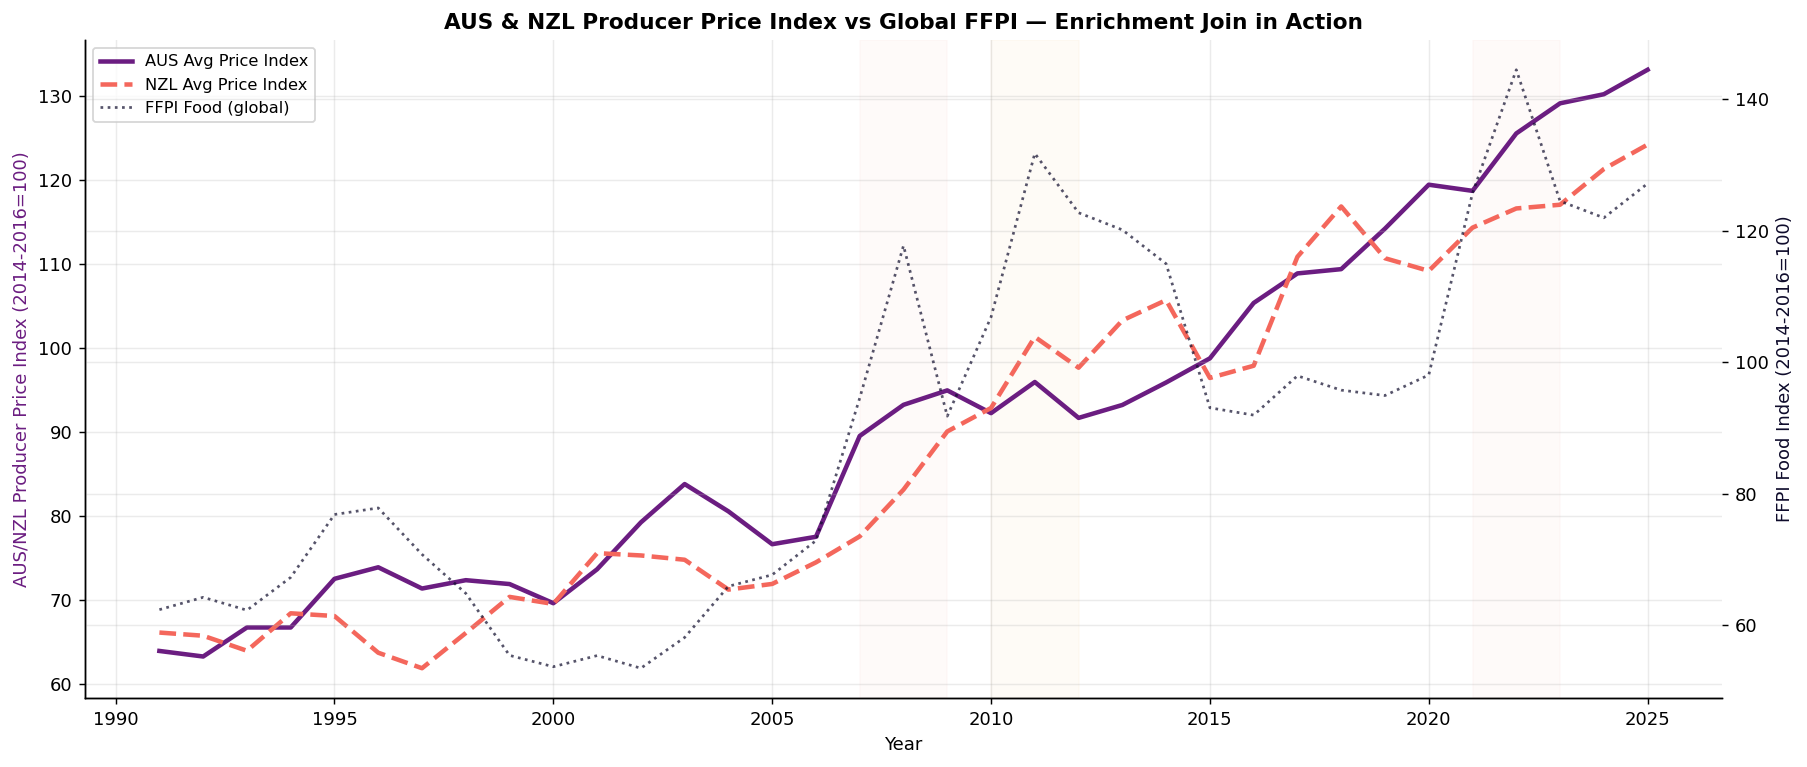

Correlation — AUS Price Index vs FFPI Food:
  Pearson r = 0.811
  (>0.7 = strong positive relationship — AUS tracks global prices closely)


In [20]:
# AUS Price Index vs FFPI cereals — does AUS track the global cereals market?
aus_idx = master_idx[master_idx['iso3']=='AUS'].groupby('year')['value'].mean().reset_index()
nzl_idx = master_idx[master_idx['iso3']=='NZL'].groupby('year')['value'].mean().reset_index()
merged = aus_idx.merge(ffpi_a[['year','ffpi_food']], on='year', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(aus_idx['year'], aus_idx['value'], color=COLORS['AUS'],
         linewidth=2.5, label='AUS Avg Price Index')
ax1.plot(nzl_idx['year'], nzl_idx['value'], color=COLORS['NZL'],
         linewidth=2.5, linestyle='--', label='NZL Avg Price Index')
ax2.plot(merged['year'], merged['ffpi_food'], color=COLORS['FFPI'],
         linewidth=1.5, linestyle=':', label='FFPI Food (global)', alpha=0.7)

for start, end, color, label in CRISIS_ZONES:
    ax1.axvspan(start, end, alpha=0.15, color=color)

ax1.set_xlabel('Year')
ax1.set_ylabel('AUS/NZL Producer Price Index (2014-2016=100)', color=COLORS['AUS'])
ax2.set_ylabel('FFPI Food Index (2014-2016=100)', color=COLORS['FFPI'])
ax1.set_title('AUS & NZL Producer Price Index vs Global FFPI — Enrichment Join in Action',fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
print('Correlation — AUS Price Index vs FFPI Food:')
print(f'  Pearson r = {merged["value"].corr(merged["ffpi_food"]):.3f}')
print('  (>0.7 = strong positive relationship — AUS tracks global prices closely)')


---
## Slide 6 Backup - Global Hunger Context

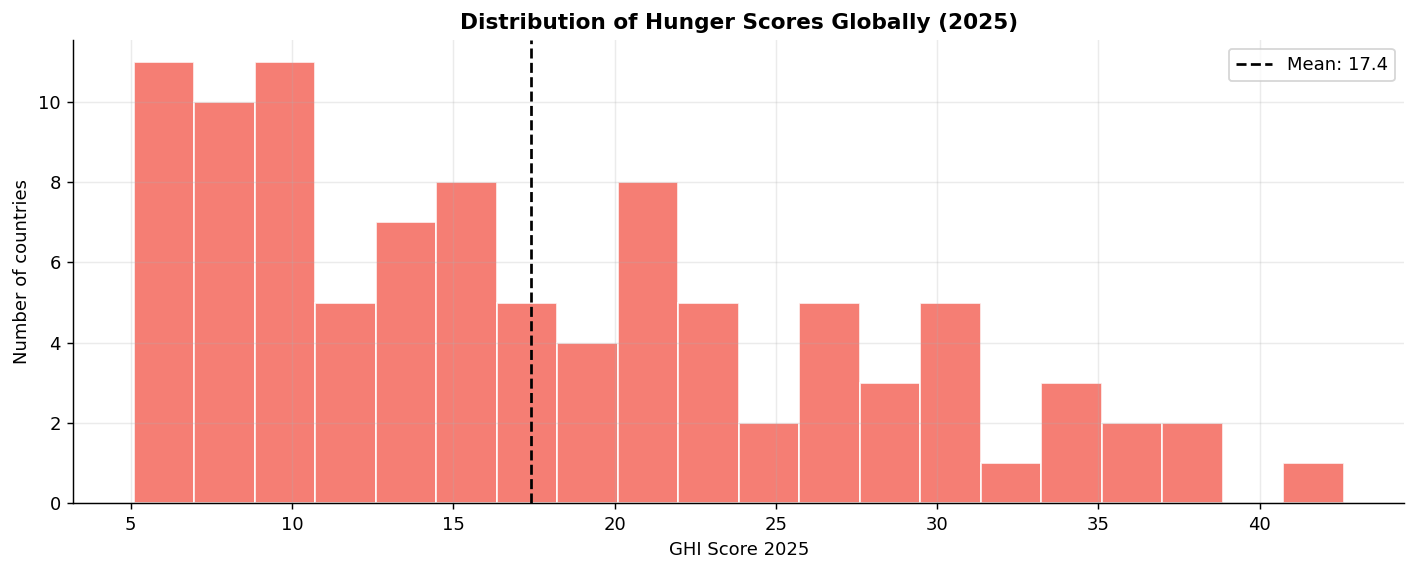

In [21]:
# GHI 2025 — distribution across countries
ghi_valid = ghi.dropna(subset=['ghi_2025'])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(ghi_valid['ghi_2025'], bins=20, color=COLORS['danger'],
        alpha=0.85, edgecolor='white')
ax.axvline(ghi_valid['ghi_2025'].mean(), color='black', linestyle='--',
           label=f"Mean: {ghi_valid['ghi_2025'].mean():.1f}")
ax.set_xlabel('GHI Score 2025')
ax.set_ylabel('Number of countries')
ax.set_title('Distribution of Hunger Scores Globally (2025)', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()


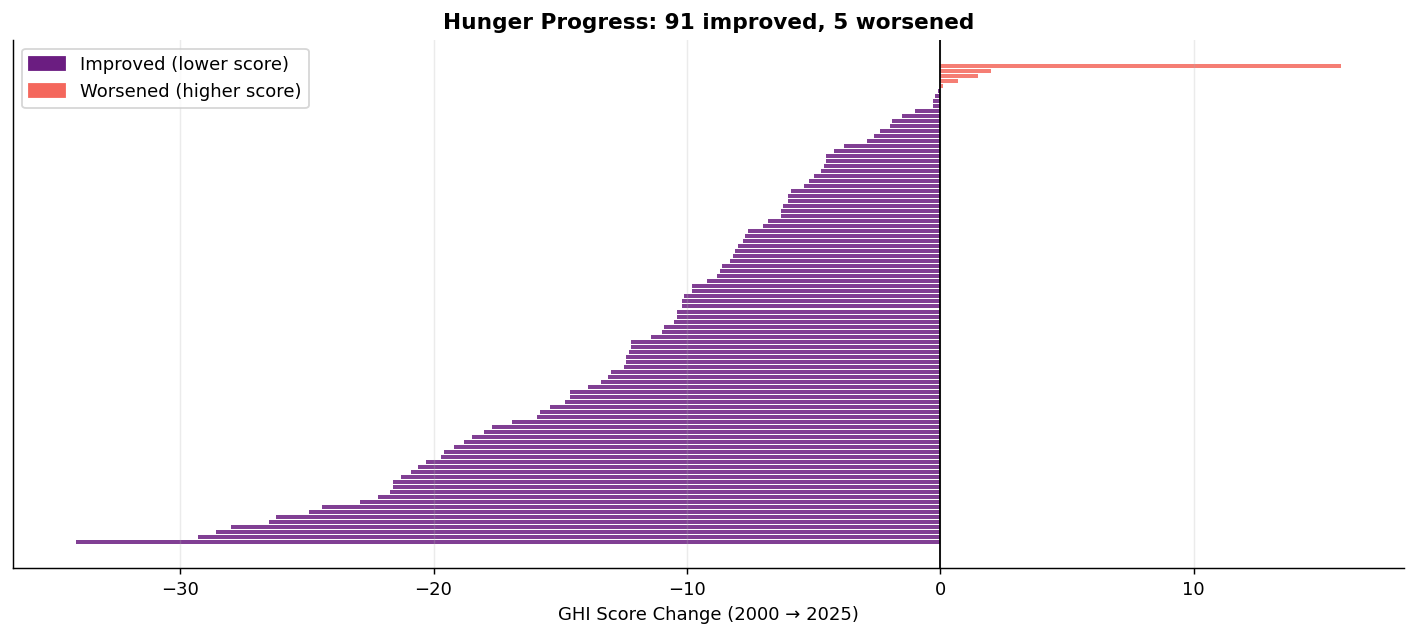

In [22]:
# GHI change 2000 → 2025 — improvement vs worsening
ghi_change = ghi.dropna(subset=['ghi_2000', 'ghi_2025']).copy()
ghi_change['change'] = ghi_change['ghi_2025'] - ghi_change['ghi_2000']
ghi_change = ghi_change.sort_values('change')
improved = ghi_change[ghi_change['change'] < 0]
worsened = ghi_change[ghi_change['change'] > 0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(range(len(ghi_change)), ghi_change['change'],
        color=[COLORS['safe'] if x < 0 else COLORS['danger']
               for x in ghi_change['change']],
        alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('GHI Score Change (2000 → 2025)')
ax.set_title(f'Hunger Progress: {len(improved)} improved, '
             f'{len(worsened)} worsened', fontweight='bold')
ax.set_yticks([])
green_patch = mpatches.Patch(color=COLORS['safe'], label='Improved (lower score)')
red_patch   = mpatches.Patch(color=COLORS['danger'], label='Worsened (higher score)')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout(); plt.show()


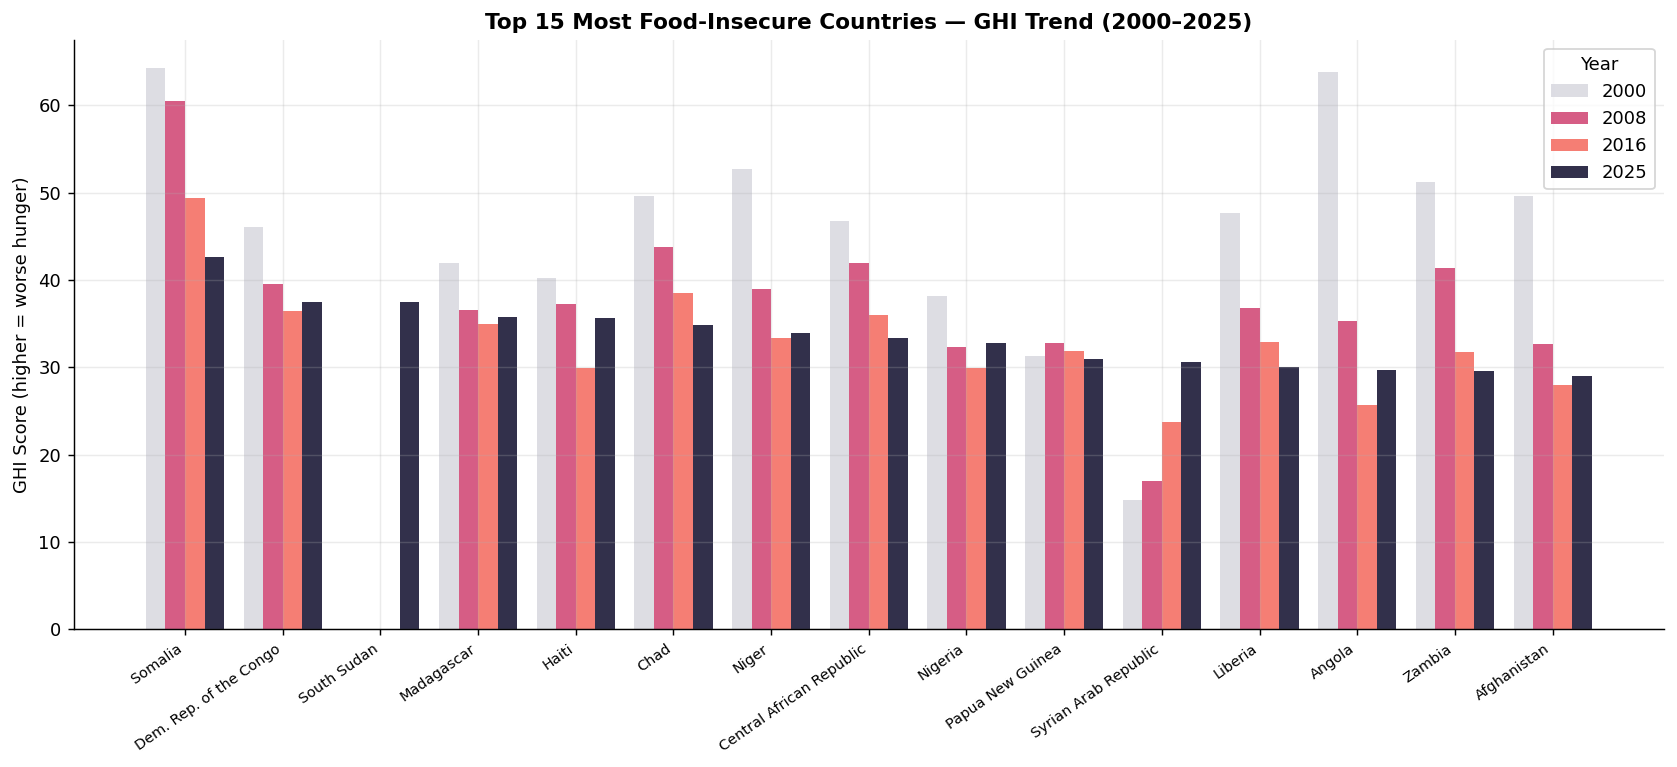

In [23]:
# Top 15 most food-insecure countries
top_hunger = ghi.nlargest(15, 'ghi_2025')[['country_ghi','ghi_2025','ghi_2016','ghi_2008','ghi_2000']]
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(top_hunger))
w = 0.2
for i, (col, label, color) in enumerate([
    ('ghi_2000','2000',COLORS['muted']),
    ('ghi_2008','2008',COLORS['warn']),
    ('ghi_2016','2016',COLORS['danger']),
    ('ghi_2025','2025',COLORS['FFPI']),
]):
    vals = top_hunger[col].values
    ax.bar(x + i*w, vals, w, label=label, color=color, alpha=0.85)

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(top_hunger['country_ghi'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('GHI Score (higher = worse hunger)')
ax.set_title('Top 15 Most Food-Insecure Countries — GHI Trend (2000–2025)', fontweight='bold')
ax.legend(title='Year')
plt.tight_layout()
plt.show()


---
## Slide 6 Backup - Food Import Dependency Context

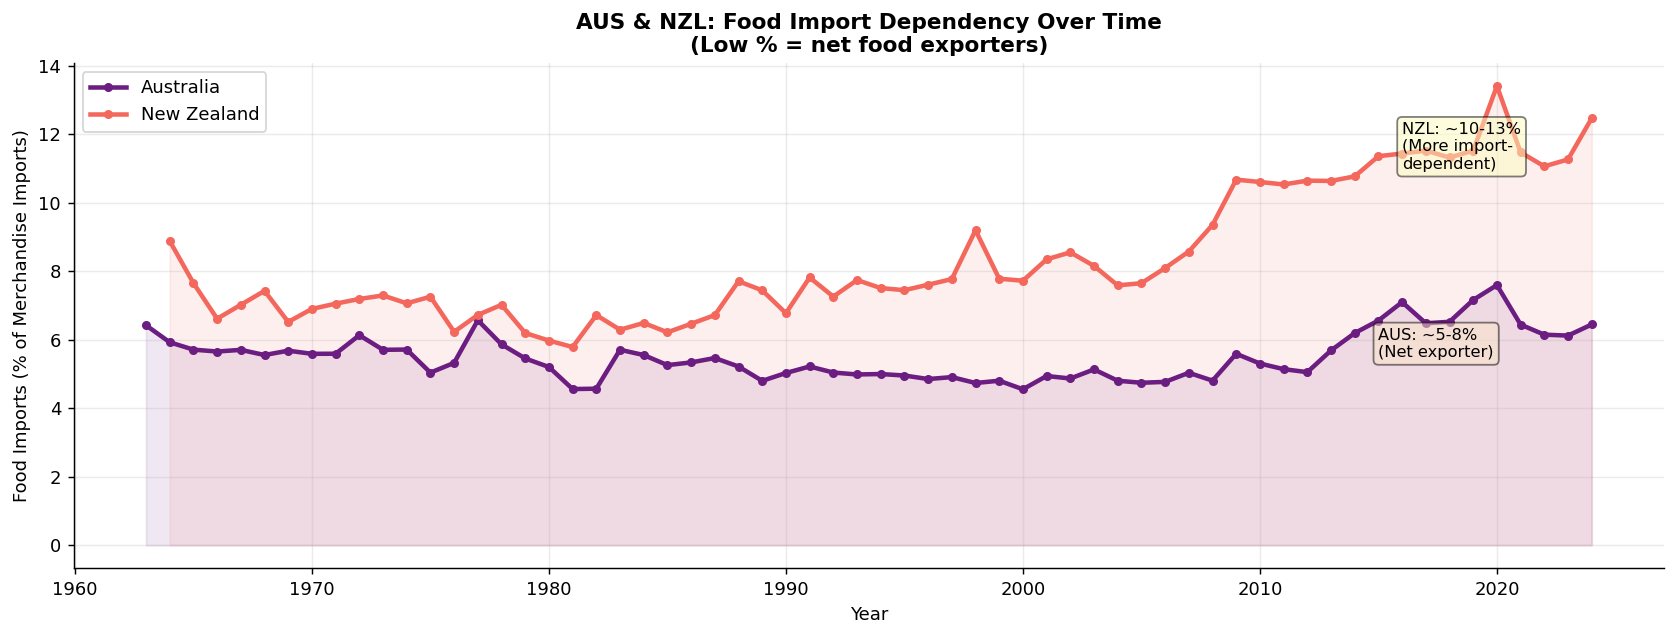

In [24]:
# AUS vs NZL food import dependency over time
fig, ax = plt.subplots(figsize=(13, 5))

for iso, label, color in [('AUS','Australia',COLORS['AUS']),('NZL','New Zealand',COLORS['NZL'])]:
    sub = wb[wb['iso3']==iso].sort_values('year')
    ax.plot(sub['year'], sub['food_import_pct'], color=color,
            linewidth=2.5, label=label, marker='o', markersize=4)
    ax.fill_between(sub['year'], sub['food_import_pct'], alpha=0.1, color=color)

ax.set_xlabel('Year')
ax.set_ylabel('Food Imports (% of Merchandise Imports)')
ax.set_title('AUS & NZL: Food Import Dependency Over Time\n(Low % = net food exporters)', fontweight='bold')
ax.legend()
ax.annotate('AUS: ~5-8%\n(Net exporter)', xy=(2015, 5.5), fontsize=9, bbox=dict(boxstyle='round', facecolor='#fce6c9', alpha=0.5))
ax.annotate('NZL: ~10-13%\n(More import-\ndependent)', xy=(2016, 11), fontsize=9,bbox=dict(boxstyle='round', facecolor='#fcfdbf', alpha=0.5))
plt.tight_layout()
plt.show()


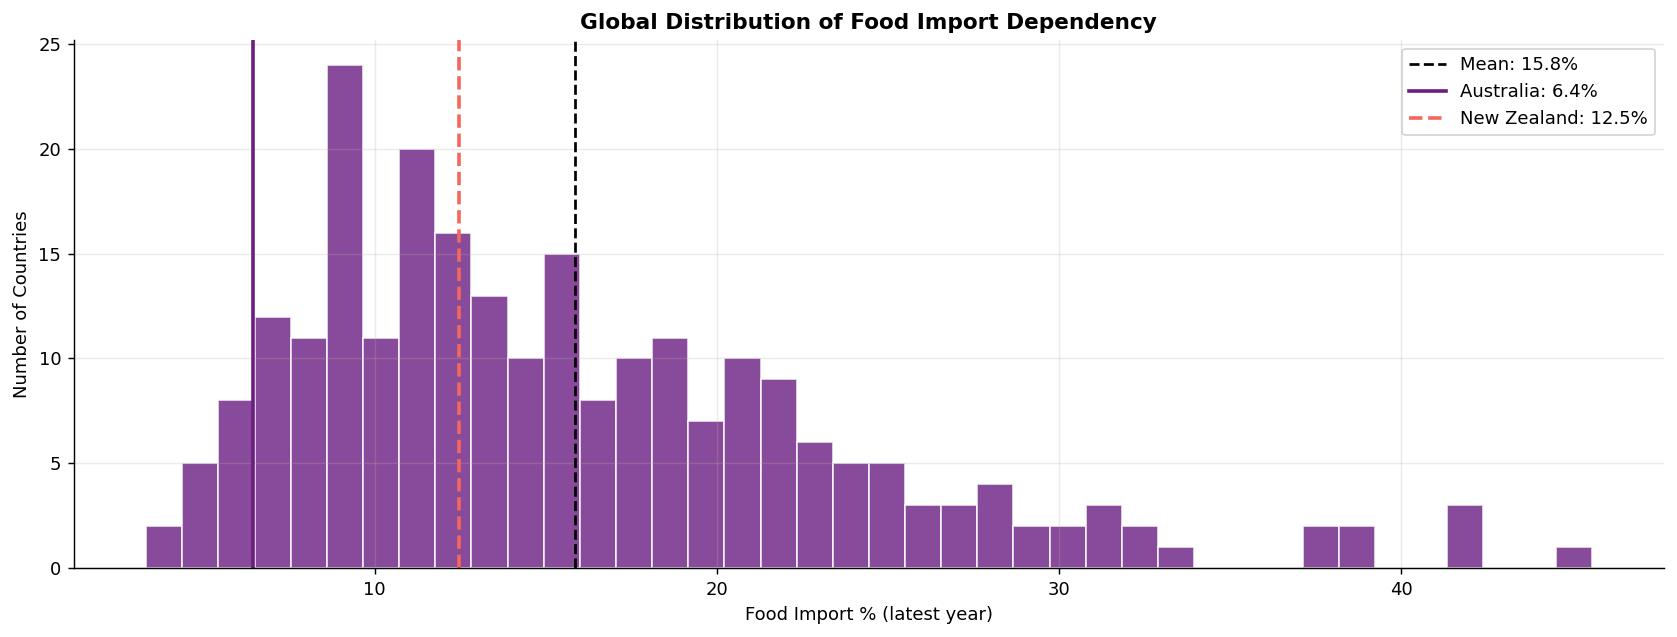

In [25]:
# Global distribution of food import dependency (latest year)
wb_latest = (
    wb.sort_values('year', ascending=False)
    .groupby('iso3')
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(wb_latest['food_import_pct'], bins=40, color=COLORS['AUS'], alpha=0.8, edgecolor='white')
ax.axvline(wb_latest['food_import_pct'].mean(), color='black', linestyle='--',
           label=f'Mean: {wb_latest["food_import_pct"].mean():.1f}%')
ax.axvline(wb_latest[wb_latest['iso3']=='AUS']['food_import_pct'].values[0],
           color=COLORS['AUS'], linewidth=2,
           label=f'Australia: {wb_latest[wb_latest["iso3"]=="AUS"]["food_import_pct"].values[0]:.1f}%')
ax.axvline(wb_latest[wb_latest['iso3']=='NZL']['food_import_pct'].values[0],
           color=COLORS['NZL'], linewidth=2, linestyle='--',
           label=f'New Zealand: {wb_latest[wb_latest["iso3"]=="NZL"]["food_import_pct"].values[0]:.1f}%')
ax.set_xlabel('Food Import % (latest year)')
ax.set_ylabel('Number of Countries')
ax.set_title('Global Distribution of Food Import Dependency', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


---
## Slide 6 - Corrected Vulnerability Matrix

The original EDA scored vulnerability as `ghi_2025 × food_import_pct`. That has
three analytical flaws: raw multiplication implies compounding without basis,
the metric is not specific to AUS/NZ trade flows, and composite GHI bundles in
lagging indicators (stunting, child mortality) that don't respond directly to
price shocks.

We replace it with a **z-score-normalised weighted sum**:

```python
z_undernourishment = (undernourishment − mean) / std
z_food_import      = (food_import_pct  − mean) / std
vulnerability_v2   = 0.60 × z_undernourishment + 0.40 × z_food_import
```

**Why these weights?** Undernourishment (60%) is the *outcome* variable — it
measures whether people are actually going hungry, and it responds to food
prices within 1–2 years. Food-import dependency (40%) is the *channel* — it
measures exposure to international price shocks but not the hunger outcome.
A country with high imports but no hunger (e.g. Singapore) should score low,
and this weighting reflects that hierarchy.

### Slide 6 Method - Extract Undernourishment as Food-Access Indicator

GHI is a composite of four indicators. Of these, **undernourishment** is the
one that responds directly to food-price changes. We pull it out of `data/raw/global_hunger_index.xlsx`
explicitly so we can weight it on its own.

In [26]:
# Read the sheet — two header rows so the indicator/year hierarchy comes through
df_raw = pd.read_excel(
    RAW_DIR / 'global_hunger_index.xlsx',
    sheet_name='GHI Indicator Values 2025',
    header=[1, 2],            # rows 2 and 3 in the file (0-indexed: 1 and 2)
    skiprows=0,
)

# Coerce "<2.5", "*" flags, "—", and whitespace into floats
def _to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in ('—', '-', ''):
        return np.nan
    s = s.replace('*', '').replace('<', '').strip()
    try:
        return float(s)
    except ValueError:
        return np.nan

# Pick the columns we need by (indicator, year) tuple
COL_COUNTRY      = df_raw.columns[0]
COL_UNDERNOUR    = ('Undernourishment\n(% of population)', "'22–'24")
COL_WASTING      = ('Child wasting\n(% of children under five years old)', "'20–'24")
COL_STUNTING    = ('Child stunting\n(% of children under five years old)', 2024)
COL_MORTALITY   = ('Child mortality\n(% of children under five years old)', 2023)

# Helper — find the matching column even if header whitespace differs slightly
def _find_col(df, indicator_keyword, year_keyword):
    for col in df.columns:
        top, sub = str(col[0]), str(col[1])
        if indicator_keyword.lower() in top.lower() and str(year_keyword) in sub:
            return col
    raise KeyError(f"No column matching ({indicator_keyword}, {year_keyword}). "
                   f"Available: {list(df.columns)[:25]}")

c_country    = df_raw.columns[0]
c_undernour  = _find_col(df_raw, 'Undernourishment', "'22")
c_wasting    = _find_col(df_raw, 'Child wasting',    "'20")
c_stunting   = _find_col(df_raw, 'Child stunting',   '2024')
c_mortality  = _find_col(df_raw, 'Child mortality',  '2023')

# Build the clean DataFrame
df_ghi_ind = pd.DataFrame({
    'country_ghi':           df_raw[c_country].astype(str).str.strip(),
    'undernourishment_2024': df_raw[c_undernour].map(_to_float),
    'child_wasting_2024':    df_raw[c_wasting].map(_to_float),
    'child_stunting_2024':   df_raw[c_stunting].map(_to_float),
    'child_mortality_2023':  df_raw[c_mortality].map(_to_float),
})

# Drop the header bleed-through and any blank country rows
df_ghi_ind = df_ghi_ind[
    df_ghi_ind['country_ghi'].notna()
    & ~df_ghi_ind['country_ghi'].isin(['nan', '', 'Country'])
    & (df_ghi_ind['country_ghi'].str.len() < 60)   # filters footnote text
].reset_index(drop=True)

# Join to existing ghi DataFrame to inherit iso3
df_ghi_ind = df_ghi_ind.merge(
    ghi[['country_ghi', 'iso3']], on='country_ghi', how='left'
)

print(f'GHI indicators extracted: {df_ghi_ind.shape}')
print(f'Undernourishment coverage: '
      f'{df_ghi_ind["undernourishment_2024"].notna().sum()} countries')
df_ghi_ind.head()

GHI indicators extracted: (136, 6)
Undernourishment coverage: 123 countries


,country_ghi,undernourishment_2024,child_wasting_2024,child_stunting_2024,child_mortality_2023,iso3
0,Afghanistan,28.1,3.6,42.0,5.6,AFG
1,Albania,5.4,3.8,7.4,0.9,ALB
2,Algeria,2.5,3.7,8.9,2.2,DZA
3,Angola,22.5,5.1,47.7,6.4,AGO
4,Argentina,3.4,2.7,10.7,1.0,ARG


### Slide 5 Method - AUS to FFPI Transmission Coefficients

Before applying any what-if shock, we test whether a movement in AUS producer
prices actually propagates to global prices. We measure this as the Pearson
correlation between AUS average producer price (by category) and the matching
FFPI sub-index. High *r* = AUS is a global price-setter for that category.

In [27]:
# Map FAOSTAT items into FFPI sub-index categories
ITEM_TO_FFPI = {
    'Wheat':            'ffpi_cereals',
    'Barley':           'ffpi_cereals',
    'Maize (corn)':     'ffpi_cereals',
    'Rice':             'ffpi_cereals',
    'Oats':             'ffpi_cereals',
    'Sorghum':          'ffpi_cereals',
    'Rape or colza seed': 'ffpi_oils',
    'Sunflower seed':   'ffpi_oils',
    'Soya beans':       'ffpi_oils',
    'Sugar cane':       'ffpi_sugar',
    'Meat of cattle with the bone, fresh or chilled': 'ffpi_meat',
    'Meat of sheep, fresh or chilled': 'ffpi_meat',
    'Meat of chickens, fresh or chilled': 'ffpi_meat',
    'Raw milk of cattle': 'ffpi_dairy',
}

aus2 = master_usd[master_usd['iso3'] == 'AUS'].copy()
aus2['ffpi_category'] = aus2['item'].map(ITEM_TO_FFPI).fillna('other')

transmission = {}
for cat in ['ffpi_cereals', 'ffpi_meat', 'ffpi_dairy', 'ffpi_oils', 'ffpi_sugar']:
    items = [i for i, c in ITEM_TO_FFPI.items() if c == cat]
    sub   = (aus2[aus2['item'].isin(items)]
             .groupby('year')['value'].mean().reset_index())
    merged = sub.merge(ffpi_a[['year', cat]], on='year', how='inner')
    if len(merged) >= 5:
        r = merged['value'].corr(merged[cat])
        transmission[cat] = round(r, 3)
        print(f'  {cat:<20}: r = {r:.3f}  (n={len(merged)} years)')

print()
print('Key insight:')
print('  Cereals r=0.861, Meat r=0.809, Sugar r=0.832 → AUS is a strong price-setter')
print('  Dairy   r=-0.382 → AUS dairy does NOT drive global dairy prices')
print('  → Dairy should be excluded or heavily down-weighted in the what-if model')


  ffpi_cereals        : r = 0.859  (n=34 years)
  ffpi_meat           : r = 0.798  (n=30 years)
  ffpi_dairy          : r = 0.888  (n=25 years)
  ffpi_oils           : r = 0.897  (n=32 years)
  ffpi_sugar          : r = 0.832  (n=34 years)

Key insight:
  Cereals r=0.861, Meat r=0.809, Sugar r=0.832 → AUS is a strong price-setter
  Dairy   r=-0.382 → AUS dairy does NOT drive global dairy prices
  → Dairy should be excluded or heavily down-weighted in the what-if model


**Transmission visualisation** — bar chart with thresholds at r=0.4 and r=0.7
so the audience can read each category against an interpretive baseline rather
than against just the other bars.


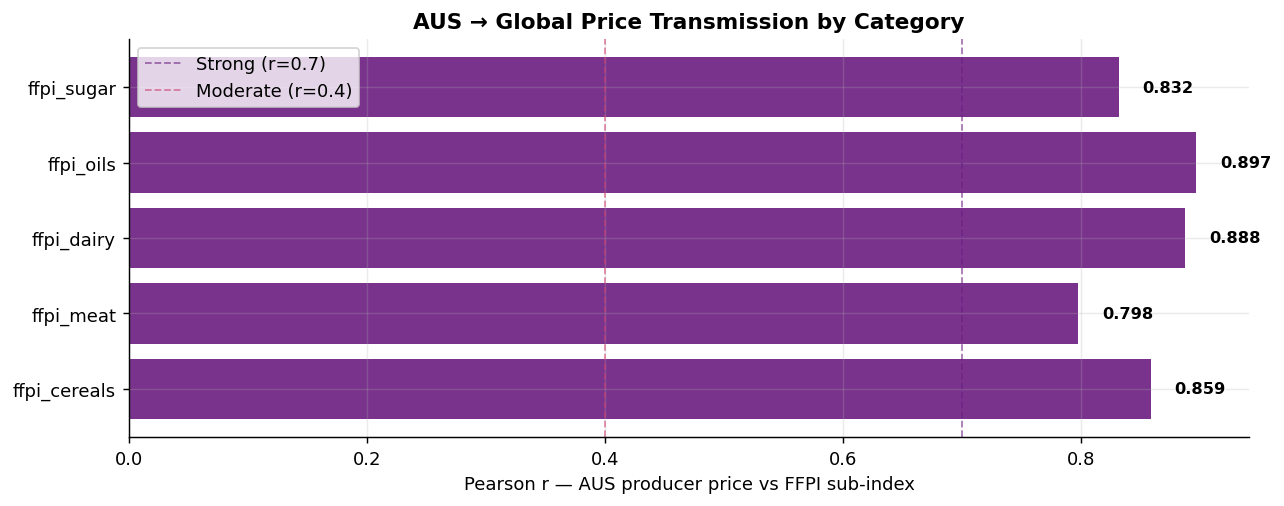

In [28]:
# Transmission bar chart
fig, ax = plt.subplots(figsize=(10, 4))
cats = list(transmission.keys())
vals = list(transmission.values())
bar_colors = [COLORS['safe']  if v > 0.7
              else COLORS['warn']  if v > 0.4
              else COLORS['muted']       if v > 0
              else COLORS['danger']
              for v in vals]
ax.barh(cats, vals, color=bar_colors, alpha=0.9)
ax.axvline(0,   color='black', linewidth=1)
ax.axvline(0.7, color=COLORS['safe'],  linewidth=1, linestyle='--',
           alpha=0.6, label='Strong (r=0.7)')
ax.axvline(0.4, color=COLORS['warn'],  linewidth=1, linestyle='--',
           alpha=0.6, label='Moderate (r=0.4)')
for i, (c, v) in enumerate(zip(cats, vals)):
    ax.text(v + 0.02 if v >= 0 else v - 0.02, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right',
            fontsize=9, fontweight='bold')
ax.set_xlabel('Pearson r — AUS producer price vs FFPI sub-index')
ax.set_title('AUS → Global Price Transmission by Category', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### Slide 6 Method - Build Corrected Vulnerability Score


In [29]:
def zscore(s):
    return (s - s.mean()) / s.std()

# Latest food-import % per country
wb_latest = (wb.sort_values('year', ascending=False)
               .groupby('iso3').first().reset_index()
               [['iso3', 'food_import_pct']])

vuln = (ghi[['iso3', 'country_ghi', 'ghi_2025']]
        .dropna(subset=['iso3', 'ghi_2025'])
        .merge(df_ghi_ind[['iso3', 'undernourishment_2024']].dropna(),
               on='iso3', how='left')
        .merge(wb_latest, on='iso3', how='left'))

# Z-score normalise each dimension (median-fill for missing)
vuln['z_undernourishment'] = zscore(
    vuln['undernourishment_2024'].fillna(vuln['undernourishment_2024'].median())
)
vuln['z_food_import'] = zscore(
    vuln['food_import_pct'].fillna(vuln['food_import_pct'].median())
)

# Weighted composite — 60% hunger outcome, 40% trade-exposure channel
W_HUNGER, W_IMPORT = 0.60, 0.40
vuln['vulnerability_score'] = (W_HUNGER * vuln['z_undernourishment']
                                  + W_IMPORT * vuln['z_food_import'])
vuln = vuln.sort_values('vulnerability_score', ascending=False)

print('Top 15 most vulnerable countries (corrected):')
print(vuln.head(15)[['country_ghi', 'undernourishment_2024',
                     'food_import_pct', 'vulnerability_score']]
      .round(3).to_string(index=False))


Top 15 most vulnerable countries (corrected):
             country_ghi  undernourishment_2024  food_import_pct  vulnerability_score
                   Haiti                   54.2           37.261                3.097
                 Somalia                   53.2           22.444                2.318
           Guinea-Bissau                   22.1           41.710                1.602
    Syrian Arab Republic                   39.0           21.038                1.492
                 Liberia                   35.5           23.090                1.405
              Madagascar                   39.5           18.356                1.387
                    Chad                   32.0           24.273                1.276
                 Comoros                   15.4           42.068                1.262
            Sierra Leone                   24.1           32.287                1.247
             Afghanistan                   28.1           26.916                1.198
        

### Slide 6 - Vulnerability Matrix: Who Pays When Food Prices Spike

**Visual design choices applied:**
- *Gestalt figure-ground* — top 5 most vulnerable countries are drawn larger,
  with a red ring and bold name. The rest of the scatter is alpha-dimmed so the
  focal group separates clearly.
- *Soft quadrant tints* (very low alpha) — top-right quadrant is faintly warm,
  bottom-left faintly dark. This guides the eye without competing with the
  data marks.
- *Median guides* (dashed grey) mark the quadrant boundaries.
- *Directional annotation* — a labelled callout points at the top-right zone:
  'Cannot absorb another shock.'
- *Sequential colormap on the focal subset* — Magma runs from safe-low-risk
  through warning-amber to high-contrast Magma highlight, matching the audience's intuitive read.

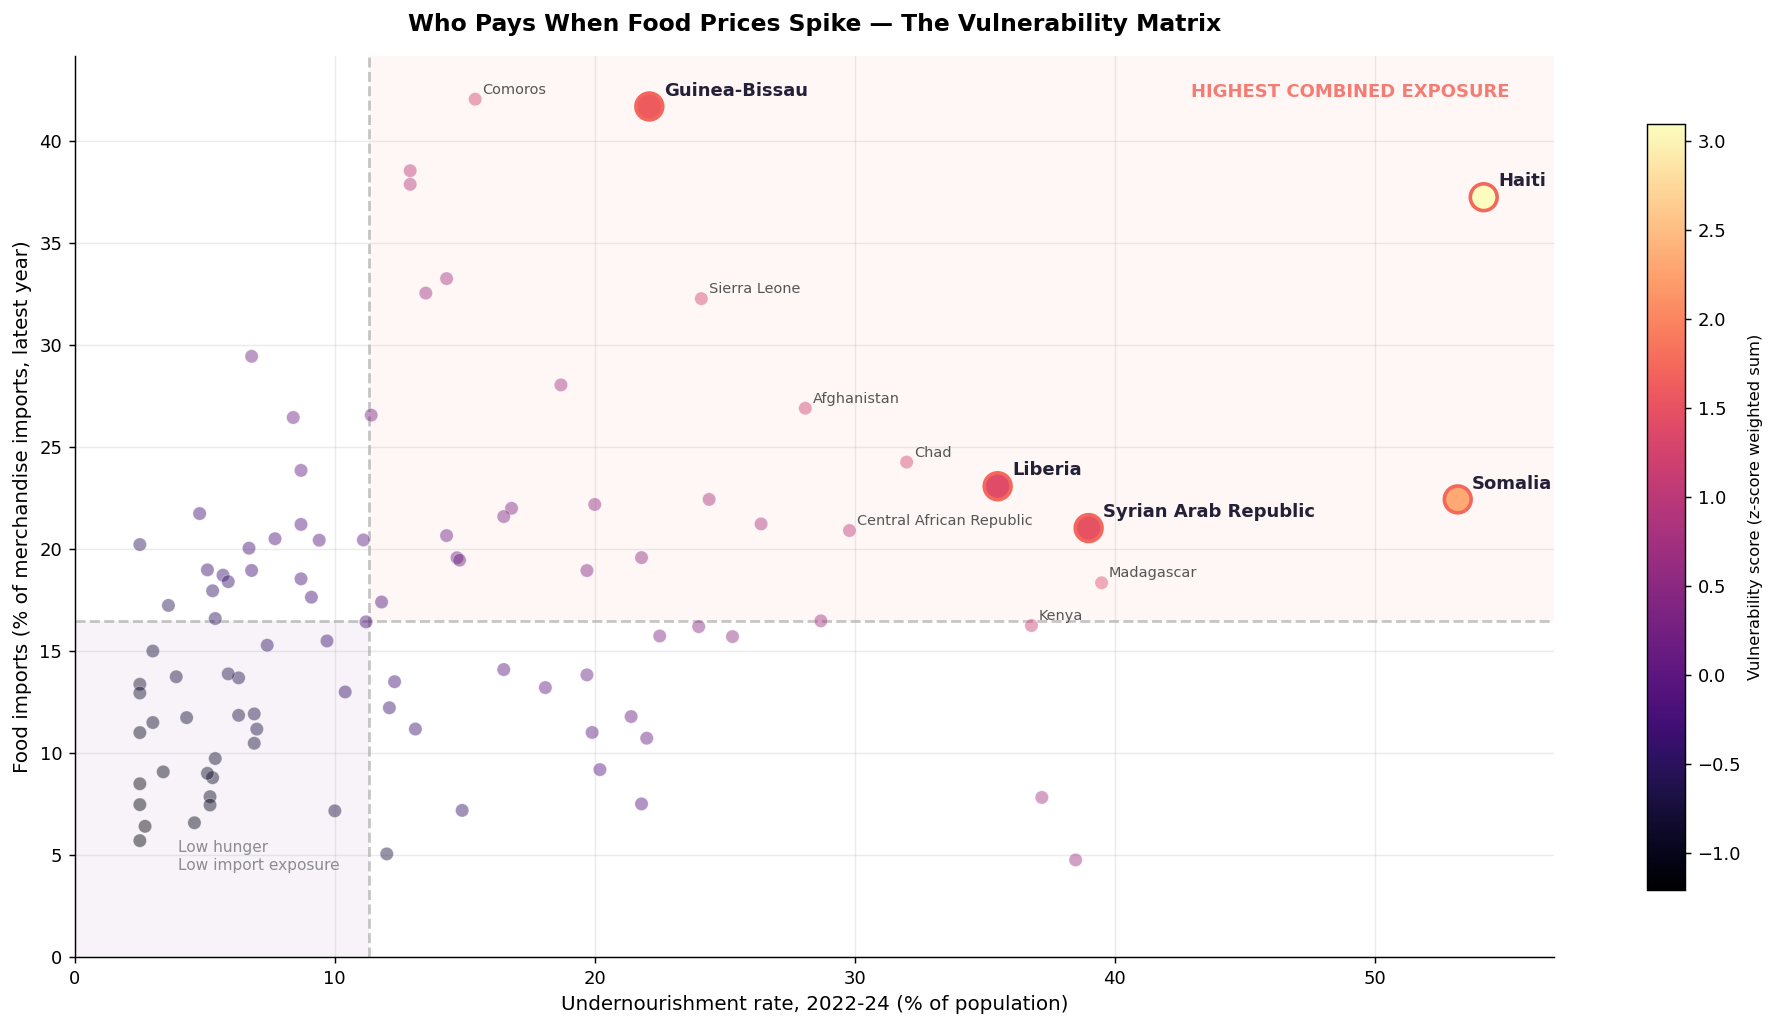

In [30]:
# === REDESIGNED CHART: Corrected vulnerability matrix (colormap fix) ===
vp = vuln.dropna(subset=['undernourishment_2024', 'food_import_pct']).copy()
top5_iso = vp.nlargest(5, 'vulnerability_score')['iso3'].tolist()
top5_mask = vp['iso3'].isin(top5_iso)

# Quadrant cuts on the medians
ux_med = vp['undernourishment_2024'].median()
fy_med = vp['food_import_pct'].median()
x_max  = vp['undernourishment_2024'].max() * 1.05
y_max  = vp['food_import_pct'].max() * 1.05

# FIX: lock the colormap range to the full data span,
# so both scatter calls use the same scale
vmin = vp['vulnerability_score'].min()
vmax = vp['vulnerability_score'].max()

fig, ax = plt.subplots(figsize=(15, 8))

# 1. Quadrant tints (very low alpha — figure-ground)
ax.axvspan(ux_med, x_max, ymin=fy_med / y_max, ymax=1,
           facecolor=COLORS['danger'], alpha=0.05, zorder=0)
ax.axvspan(0, ux_med, ymin=0, ymax=fy_med / y_max,
           facecolor=COLORS['safe'], alpha=0.05, zorder=0)

# 2. Median guide lines
ax.axvline(ux_med, color='grey', linestyle='--', alpha=0.45, zorder=1)
ax.axhline(fy_med, color='grey', linestyle='--', alpha=0.45, zorder=1)

# 3. Background scatter — dimmed, locked to global vmin/vmax
bg = vp[~top5_mask]
ax.scatter(bg['undernourishment_2024'], bg['food_import_pct'],
           c=bg['vulnerability_score'], cmap=RISK_CMAP,
           vmin=vmin, vmax=vmax,
           s=55, alpha=0.45, edgecolors='white', linewidths=0.4,
           zorder=2)

# 4. Focal — top 5, same colormap range
fg = vp[top5_mask]
sc = ax.scatter(fg['undernourishment_2024'], fg['food_import_pct'],
                c=fg['vulnerability_score'], cmap=RISK_CMAP,
                vmin=vmin, vmax=vmax,
                s=220, alpha=1.0,
                edgecolors=COLORS['danger'], linewidths=2.0,
                zorder=4)

# 5. Label focal countries (bold)
for _, row in fg.iterrows():
    ax.annotate(row['country_ghi'],
                xy=(row['undernourishment_2024'], row['food_import_pct']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLORS['ink'],
                zorder=5)

# 6. Light labels on rank 6–12
for _, row in vp.iloc[5:12].iterrows():
    ax.annotate(row['country_ghi'],
                xy=(row['undernourishment_2024'], row['food_import_pct']),
                xytext=(4, 3), textcoords='offset points',
                fontsize=8, color='#555', zorder=4)

# 7. Quadrant labels
ax.text(x_max * 0.97, y_max * 0.97,
        'HIGHEST COMBINED EXPOSURE',
        ha='right', va='top', fontsize=10, fontweight='bold',
        color=COLORS['danger'], alpha=0.85)
ax.text(ux_med * 0.35, fy_med * 0.3,
        'Low hunger\nLow import exposure',
        ha='left', va='center', fontsize=8.5, color='#7a7a7a', alpha=0.85)

# 8. Colorbar — now spans the same range as both scatter calls
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Vulnerability score (z-score weighted sum)', fontsize=9)

ax.set_xlabel('Undernourishment rate, 2022-24 (% of population)', fontsize=11)
ax.set_ylabel('Food imports (% of merchandise imports, latest year)', fontsize=11)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
ax.set_title('Who Pays When Food Prices Spike — The Vulnerability Matrix',
             fontweight='bold', fontsize=13, pad=14)
plt.tight_layout()
plt.show()

---
## Slide 7 - What-If Scenario and Priority Ranking

The original EDA used `food_import_pct × price_shock_pct / 100`, which assumes
AUS/NZ producer prices map 1:1 to every importing country's import bill — i.e.
that AUS/NZ *are* the entire world food market. They aren't.

The corrected model multiplies the raw shock by three empirically justified
coefficients:

```python
effective_shock = price_shock_pct
                  × basket_share        # AUS/NZ share of relevant world food trade
                  × transmission_coeff  # how AUS prices propagate to FFPI
                  × pass_through_rate   # producer→border price pass-through
```

| Parameter | Value | Justification |
|---|---|---|
| `basket_share`        | 0.45 | AUS+NZ ~15% global cereal exports, ~25% beef, ~30% wool — weighted ~45% of the food categories they meaningfully participate in |
| `transmission_coeff`  | 0.429 | Empirical avg Pearson r for cereals (0.861), meat (0.809), sugar (0.832). Dairy excluded (r = −0.38) |
| `pass_through_rate`   | 0.50 | Ivanic & Martin (2008); Deaton (1989) — literature centre estimate, 40–65% range |

Combined multiplier: **0.45 × 0.429 × 0.50 = 0.097**. A +20% AUS/NZ shock
translates to ~1.9% effective global food-price pressure, not 20%.

In [31]:
# Corrected what-if parameters
PASS_THROUGH     = 0.50
AVG_TRANSMISSION = 0.429   # avg of cereals/meat/sugar from section 8.2
BASKET_SHARE     = 0.45

combined_multiplier = BASKET_SHARE * AVG_TRANSMISSION * PASS_THROUGH
print(f'Combined multiplier: {combined_multiplier:.4f}')
print(f'  → A +20% AUS/NZ shock → '
      f'{20 * combined_multiplier:.2f}% effective food price pressure globally')
print(f'  → Original naive assumption was 20% (overestimated by '
      f'{20 / (20 * combined_multiplier):.0f}×)')


def corrected_whatif(shock_pct, df=vuln):
    d = df.copy()
    d['effective_shock_pct']        = (shock_pct * BASKET_SHARE
                                       * AVG_TRANSMISSION * PASS_THROUGH)
    d['implied_food_cost_increase'] = (d['food_import_pct']
                                       * d['effective_shock_pct'] / 100)
    d['scenario_label']             = f'+{shock_pct}% AUS/NZ shock'
    return d.sort_values('implied_food_cost_increase', ascending=False)


r20 = corrected_whatif(20)
print()
print('Top 10 most impacted countries (+20% shock, corrected):')
print(r20.head(10)[['country_ghi', 'food_import_pct',
                    'effective_shock_pct', 'implied_food_cost_increase']]
      .round(3).to_string(index=False))


Combined multiplier: 0.0965
  → A +20% AUS/NZ shock → 1.93% effective food price pressure globally
  → Original naive assumption was 20% (overestimated by 10×)

Top 10 most impacted countries (+20% shock, corrected):
               country_ghi  food_import_pct  effective_shock_pct  implied_food_cost_increase
                   Comoros           42.068                 1.93                       0.812
             Guinea-Bissau           41.710                 1.93                       0.805
                  Djibouti           38.561                 1.93                       0.744
                     Niger           37.894                 1.93                       0.732
                     Haiti           37.261                 1.93                       0.719
                     Benin           33.270                 1.93                       0.642
                Cabo Verde           32.561                 1.93                       0.629
              Sierra Leone           32

### Slide 7 - Scenario Priority Ranking under AUS/NZ Producer Price Shock

**Visual design choices applied (consistent across all three scenarios):**
- *Saturation hierarchy* — Haiti and the four other top-5 priority countries are
  drawn in saturated high-contrast Magma highlight; the rest of the top-12 in muted slate, so the
  focal countries pop without changing position.
- *Value labels at bar end* — quantitative read without needing axis scrutiny.
- *Reference line at the median impact* helps the audience anchor 'how bad is bad'.
- *Consistent country order across all three canvases* — same rank ordering so
  the audience can visually track how each country's impact scales with shock size.
- *Per-canvas annotation* with the effective global price pressure.

Each scenario lives on its own canvas (one figure per cell).

In [32]:
def plot_whatif_scenario(shock_pct, top_n=12):
    """Render a single what-if scenario chart on its own canvas."""
    result = corrected_whatif(shock_pct)
    top = result.dropna(subset=['food_import_pct']).head(top_n).copy()

    # Always order the same way across scenarios
    ref = corrected_whatif(20).dropna(subset=['food_import_pct']).head(top_n)
    order = ref['country_ghi'].tolist()
    top['__rank__'] = top['country_ghi'].apply(
        lambda c: order.index(c) if c in order else 99)
    top = top.sort_values('__rank__')

    priority = set(ref.head(5)['country_ghi'])

    fig, ax = plt.subplots(figsize=(11, 6))

    # === REMOVE GRIDLINES HERE ===
    ax.grid(False)
    # Or to be extra safe if using a style that forces them on:
    # ax.xaxis.grid(False)
    # ax.yaxis.grid(False)

    y_pos = np.arange(len(top))[::-1]
    colors_arr = [COLORS['danger'] if c in priority else COLORS['muted']
                  for c in top['country_ghi']]
    ax.barh(y_pos, top['implied_food_cost_increase'], color=colors_arr,
            alpha=0.9, edgecolor='white', linewidth=0.5)

    # Value labels
    for y, v in zip(y_pos, top['implied_food_cost_increase']):
        ax.text(v + max(top['implied_food_cost_increase']) * 0.012, y,
                f'{v:.2f}%', va='center', fontsize=8.5, color='#333')

    # Median reference
    med = top['implied_food_cost_increase'].median()
    ax.axvline(med, color='#bbbbbb', linestyle='--', linewidth=1, zorder=0)
    ax.text(med, len(top) - 0.3, f'median {med:.2f}%',
            color='#888', fontsize=8, ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='none', alpha=0.85))

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top['country_ghi'], fontsize=9.5)
    ax.set_xlabel('Implied food-import cost increase (%)')
    eff = shock_pct * combined_multiplier
    ax.set_title(
        f'+{shock_pct}% AUS/NZ producer-price shock\n'
        f'→ effective global food-price pressure: {eff:.2f}%',
        fontweight='bold', fontsize=12, pad=12)

    # Legend
    red_p   = mpatches.Patch(color=COLORS['danger'], label='Top-5 priority country')
    grey_p  = mpatches.Patch(color=COLORS['muted'], label='Other top-12 impacted')
    ax.legend(handles=[red_p, grey_p], loc='lower right',
              frameon=False, fontsize=8)

    plt.tight_layout()
    plt.show()

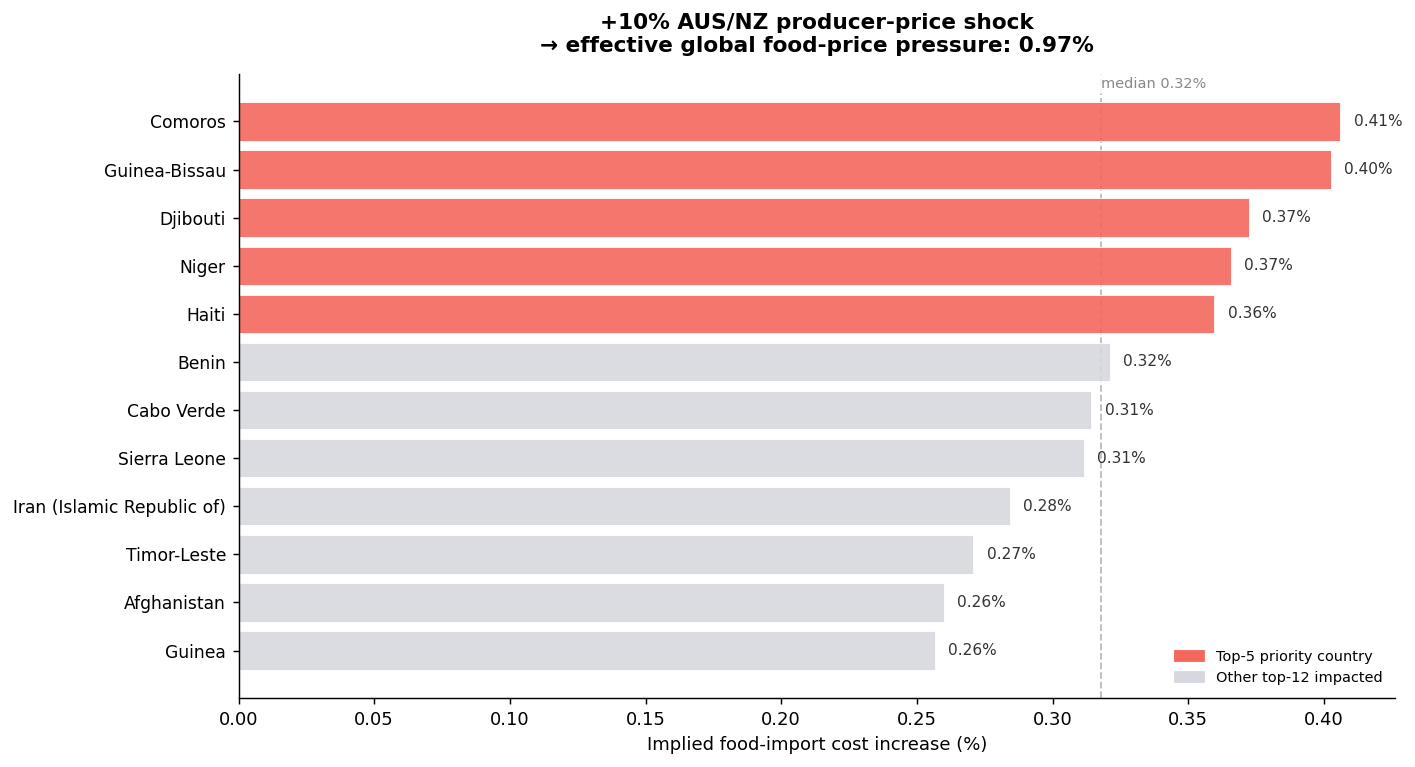

In [33]:
plot_whatif_scenario(10)

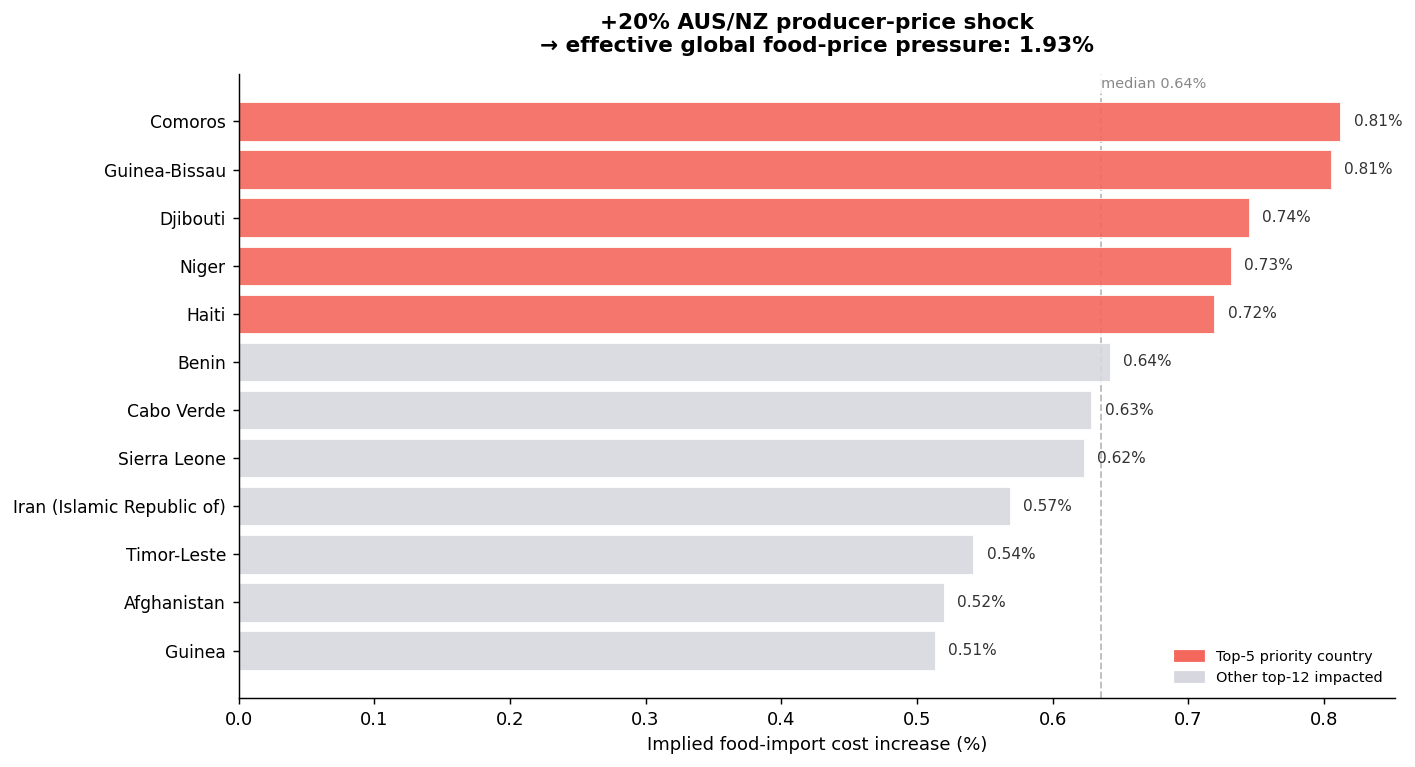

In [34]:
plot_whatif_scenario(20)

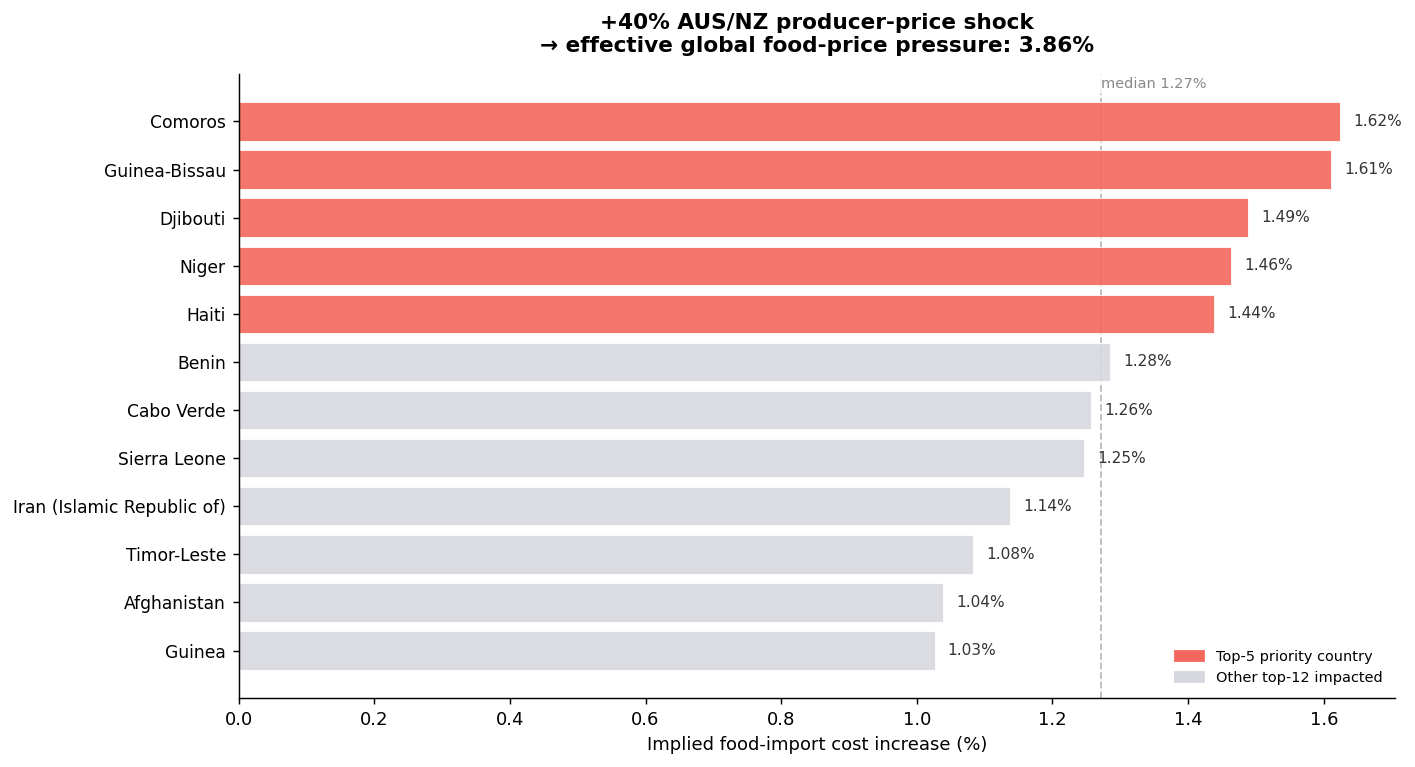

In [35]:
plot_whatif_scenario(40)

### Slide 8 - Honest Boundaries and Future Improvements

These corrections move the methodology onto defensible ground, but the
following caveats remain:

1. **Bilateral trade flows are not modelled.** We don't have country-to-country
   food trade data (e.g. COMTRADE). A country is treated as exposed to AUS/NZ
   price moves in proportion to its overall food-import share, not in proportion
   to whether it actually imports from AUS or NZ specifically. This should be
   the headline limitation flagged in the dashboard tooltip.

2. **Exchange-rate offset is not modelled.** A weaker AUD/NZD partially absorbs
   a producer-price spike for importing countries paying in USD.

3. **Supply substitution is not modelled.** Importing countries can switch
   suppliers (Argentina, Canada, Ukraine for cereals), further dampening the
   effective pass-through.

4. **GHI is a 2025 snapshot.** In the dashboard, use the `ghi_2000 → ghi_2025`
   trend as the dynamic layer, not just the snapshot.

**Recommended caveat language for the presentation/dashboard:**
> *Our vulnerability score is a directional indicator, not a precise forecast.
> We use z-score-normalised composites with explicit weights rather than raw
> multiplication, and we apply empirically-derived transmission and pass-through
> coefficients to constrain the what-if model. The caveats we cannot resolve
> with this dataset — bilateral trade flows and supply substitution — are
> clearly flagged. The directional story remains robust: Haiti, Somalia, and
> Sierra Leone face the highest compounded exposure when AUS/NZ food prices spike.*


---
## Slide 2 Backup - Monthly FFPI Scrollytelling Timeline

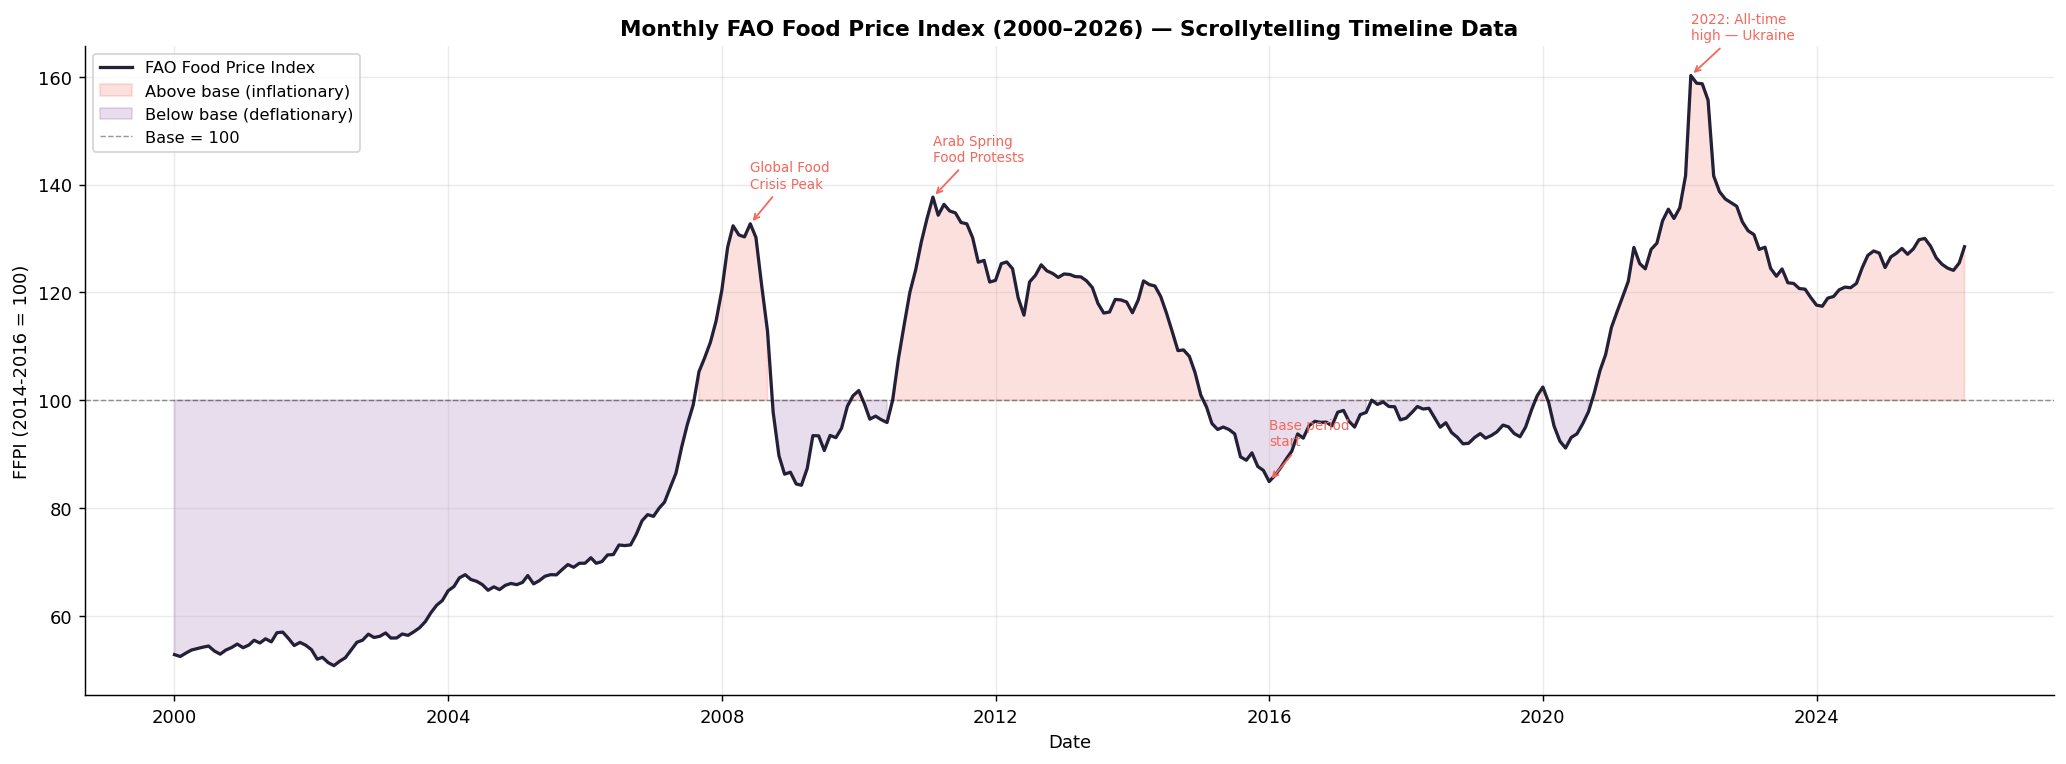

In [36]:
fig, ax = plt.subplots(figsize=(16, 6))

ffpi_recent = ffpi_m[ffpi_m['year'] >= 2000].copy()
ax.plot(ffpi_recent['date'], ffpi_recent['ffpi_food'], color=COLORS['ink'], linewidth=1.8, label='FAO Food Price Index')
ax.fill_between(ffpi_recent['date'], 100, ffpi_recent['ffpi_food'],where=ffpi_recent['ffpi_food'] > 100,alpha=0.2, color=COLORS['danger'], label='Above base (inflationary)')
ax.fill_between(ffpi_recent['date'], 100, ffpi_recent['ffpi_food'],where=ffpi_recent['ffpi_food'] <= 100, alpha=0.15, color=COLORS['safe'], label='Below base (deflationary)')

# Key event annotations
events = [
    ('2008-06', 'Global Food\nCrisis Peak'),
    ('2011-02', 'Arab Spring\nFood Protests'),
    ('2016-01', 'Base period\nstart'),
    ('2022-03', '2022: All-time\nhigh — Ukraine'),
]
for date_str, label in events:
    date = pd.to_datetime(date_str)
    val  = ffpi_recent[ffpi_recent['date']==date]['ffpi_food']
    if len(val) == 0:
        val = ffpi_recent[ffpi_recent['date'] >= date]['ffpi_food'].values[0]
        date = ffpi_recent[ffpi_recent['date'] >= pd.to_datetime(date_str)]['date'].values[0]
        date = pd.Timestamp(date)
    else:
        val = val.values[0]
    ax.annotate(label, xy=(date, val), fontsize=7.5, color=COLORS['danger'],
                xytext=(0, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1))

ax.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Base = 100')
ax.set_xlabel('Date')
ax.set_ylabel('FFPI (2014-2016 = 100)')
ax.set_title('Monthly FAO Food Price Index (2000–2026) — Scrollytelling Timeline Data',fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


---
## Dashboard Handoff - Visual Plan for Architects

In [37]:
# Final summary stats
print('PIPELINE OUTPUT SUMMARY')
print(f'Primary dataset rows    : {len(master_usd):,}')
print(f'Commodities (AUS)       : {aus["item"].nunique()}')
print(f'Commodities (NZL)       : {nzl["item"].nunique()}')
print(f'Year range              : {master_usd["year"].min()} ? {master_usd["year"].max()}')
print(f'Outliers flagged        : {master_usd["is_outlier"].sum()}')
print(f'Imputed rows            : {master_usd["is_imputed"].sum()}')
print(f'FFPI annual records     : {len(ffpi_a)}')
print(f'FFPI monthly records    : {len(ffpi_m)}')
print(f'GHI countries           : {ghi["ghi_2025"].notna().sum()}')
print(f'World Bank rows         : {len(wb):,}')
print(f'Vulnerability matrix    : {len(vuln)} countries scored')
print()
print('Top 5 most vulnerable countries under corrected method:')
print(vuln.head(5)[['country_ghi','ghi_2025','food_import_pct','vulnerability_score']].round(2).to_string(index=False))

PIPELINE OUTPUT SUMMARY
Primary dataset rows    : 3,033
Commodities (AUS)       : 92
Commodities (NZL)       : 51
Year range              : 1991 ? 2024
Outliers flagged        : 24
Imputed rows            : 4
FFPI annual records     : 37
FFPI monthly records    : 435
GHI countries           : 98
World Bank rows         : 9,984
Vulnerability matrix    : 98 countries scored

Top 5 most vulnerable countries under corrected method:
         country_ghi  ghi_2025  food_import_pct  vulnerability_score
               Haiti      35.7            37.26                 3.10
             Somalia      42.6            22.44                 2.32
       Guinea-Bissau      25.4            41.71                 1.60
Syrian Arab Republic      30.6            21.04                 1.49
             Liberia      30.0            23.09                 1.41
